# 1. Decoding Transaction Dynamics on PhonePe - Aggregated Transaction

In [1]:
from dotenv import load_dotenv
import os
import mysql.connector
import pandas as pd

# Load environment variables
load_dotenv()

conn = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

query = "SELECT * FROM aggregated_transaction;"
df = pd.read_sql(query, conn)

df.head()

C:\Users\Vigne\AppData\Local\Temp\ipykernel_6728\4006966670.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,1,maharashtra,2023,2,Merchant payments,1289778683,5.677135e+11
1,2,maharashtra,2023,2,Peer-to-peer payments,620475611,1.923753e+12
2,3,maharashtra,2023,2,Recharge & bill payments,151613474,1.128466e+11
3,4,maharashtra,2023,2,Financial Services,697164,8.210617e+08
4,5,maharashtra,2023,2,Others,1152916,8.706934e+08


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sklearn


In [ ]:
# Case study 1: Aggregated_Transaction

In [3]:
agg_txn = pd.read_sql("SELECT * FROM aggregated_transaction", conn)

print("Data loaded ✅")
print(agg_txn.shape)

Data loaded ✅
(5034, 7)


C:\Users\Vigne\AppData\Local\Temp\ipykernel_6728\2037270357.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  agg_txn = pd.read_sql("SELECT * FROM aggregated_transaction", conn)


In [4]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [5]:
agg_txn.head()

,id,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,1,maharashtra,2023,2,Merchant payments,1289778683,"567,713,506,184"
1,2,maharashtra,2023,2,Peer-to-peer payments,620475611,"1,923,752,701,888"
2,3,maharashtra,2023,2,Recharge & bill payments,151613474,"112,846,643,294"
3,4,maharashtra,2023,2,Financial Services,697164,"821,061,690"
4,5,maharashtra,2023,2,Others,1152916,"870,693,412"


In [6]:
agg_txn.columns

Index(['id', 'state', 'year', 'quarter', 'transaction_type',
       'transaction_count', 'transaction_amount'],
      dtype='str')

In [7]:
agg_txn.shape

(5034, 7)

In [27]:
agg_txn.info()

<class 'pandas.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5034 non-null   int64  
 1   state               5034 non-null   str    
 2   year                5034 non-null   int64  
 3   quarter             5034 non-null   int64  
 4   transaction_type    5034 non-null   str    
 5   transaction_count   5034 non-null   int64  
 6   transaction_amount  5034 non-null   float64
dtypes: float64(1), int64(4), str(2)
memory usage: 275.4 KB


In [9]:
agg_txn.describe()

,id,year,quarter,transaction_count,transaction_amount
count,"5,034","5,034","5,034","5,034","5,034"
mean,"2,518","2,021",3,"46,739,018","68,637,722,454"
std,"1,453",2,1,"169,096,817","268,519,963,110"
min,1,"2,018",1,2,34
25%,"1,259","2,019",2,"58,090","39,938,880"
50%,"2,518","2,021",3,"515,831","439,413,885"
75%,"3,776","2,023",4,"11,666,286","11,028,222,172"
max,"5,034","2,024",4,"2,393,917,535","3,095,666,288,407"


## Statewise Total Transaction Value.

In [10]:
state_txn = (
    agg_txn
    .groupby("state")["transaction_amount"]
    .sum()
    .sort_values(ascending=False)
)

state_txn.head(10)

state
telangana        41,655,955,630,076
karnataka        40,678,721,773,666
maharashtra      40,374,195,687,972
andhra-pradesh   34,669,080,454,847
uttar-pradesh    26,885,212,184,900
rajasthan        26,343,235,566,259
madhya-pradesh   19,125,279,433,027
bihar            17,901,349,344,780
west-bengal      15,584,164,309,414
odisha           12,263,982,051,533
Name: transaction_amount, dtype: float64

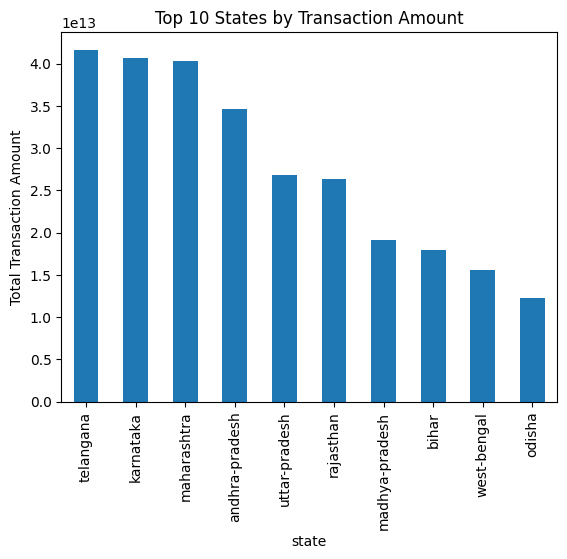

In [11]:
import matplotlib.pyplot as plt

state_txn.head(10).plot(kind="bar")
plt.title("Top 10 States by Transaction Amount")
plt.ylabel("Total Transaction Amount")
plt.show()

Insight 1: Telangana, Karnataka, and Maharashtra contribute the highest transaction value, indicating strong digital adoption in economically active states.

Business Recommendation: Prioritize premium services and cross-selling financial products in these high-volume states.

## Quarter-Wise Trend (Growth or Decline)

In [12]:
quarter_trend = (
     agg_txn
    .groupby(["year", "quarter"])["transaction_amount"]
    .sum()
    .reset_index()
)

quarter_trend

,year,quarter,transaction_amount
0,2018,1,"171,833,431,017"
1,2018,2,"304,374,211,667"
2,2018,3,"475,101,505,615"
3,2018,4,"671,736,248,114"
4,2019,1,"990,021,362,111"
5,2019,2,"1,354,214,037,093"
6,2019,3,"1,672,558,991,160"
7,2019,4,"2,259,893,742,825"
8,2020,1,"2,697,112,477,804"
9,2020,2,"2,646,145,107,973"


In [13]:
quarter_trend["date"] = pd.to_datetime(
    quarter_trend["year"].astype(str) + 
    "Q" + 
    quarter_trend["quarter"].astype(str)
)

quarter_trend = quarter_trend.sort_values("date")

C:\Users\Vigne\AppData\Local\Temp\ipykernel_13440\2869360425.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  quarter_trend["date"] = pd.to_datetime(


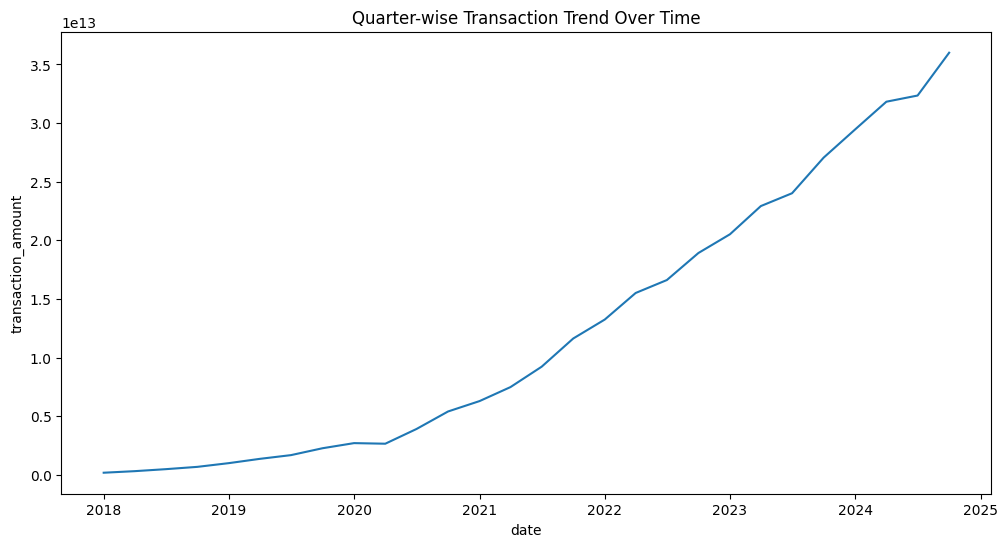

In [14]:
plt.figure(figsize=(12,6))
sns.lineplot(data=quarter_trend, x="date", y="transaction_amount")

plt.title("Quarter-wise Transaction Trend Over Time")
plt.show()

Insight 1:
PhonePe has experienced sustained quarter-on-quarter growth since 2018, indicating strong and accelerating digital payment adoption across India.

Business Meaning: The platform is in expansion phase, not maturity or decline.

Insight 2:Transaction growth accelerated significantly post-2020, likely driven by increased digital adoption, UPI expansion, and behavioral shifts toward contactless payments.

Business Meaning: Structural shift, not temporary spike.

Insight 3:No prolonged stagnation periods are observed, suggesting strong user retention and expanding transaction frequency.

Insight 4: The increasingly steep growth curve indicates network effects, where expanding user and merchant bases reinforce transaction growth.

Insight 5:Growth momentum remains strong through 2024, indicating the market has not yet reached saturation.

## Category Analysis

In [15]:
category_analysis = (
    agg_txn
    .groupby("transaction_type")["transaction_amount"]
    .sum()
    .sort_values(ascending=False)
)

category_analysis

transaction_type
Peer-to-peer payments      266,527,358,971,212
Merchant payments           65,339,877,074,733
Recharge & bill payments    13,338,759,360,278
Others                         174,280,661,976
Financial Services             142,018,767,186
Name: transaction_amount, dtype: float64

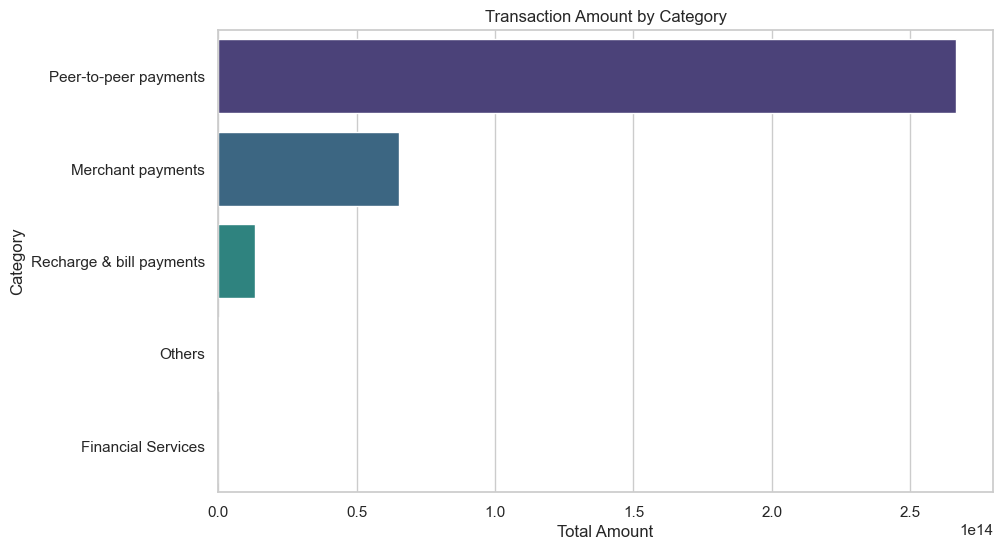

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(
    x=category_analysis.values, 
    y=category_analysis.index, 
    hue=category_analysis.index, 
    palette="viridis",
    legend=False
)

plt.title("Transaction Amount by Category")
plt.xlabel("Total Amount")
plt.ylabel("Category")
plt.show()

Insight 3

Peer-to-peer transactions dominate, while insurance-related transactions contribute minimal share — indicating untapped cross-sell opportunity.

## Category Growth Rate Comparison

In [28]:
category_year = (
    agg_txn.groupby(["transaction_type", "year"])["transaction_amount"]
    .sum()
    .reset_index()
)

category_year["growth"] = (
    category_year.groupby("transaction_type")["transaction_amount"]
    .pct_change() * 100
)

category_year.sort_values("growth", ascending=False)

,transaction_type,year,transaction_amount,growth
8,Merchant payments,2019,"411,440,224,219",626
22,Peer-to-peer payments,2019,"5,488,757,106,962",283
9,Merchant payments,2020,"1,548,367,322,904",276
2,Financial Services,2020,"8,457,813,149",265
10,Merchant payments,2021,"5,270,794,177,558",240
29,Recharge & bill payments,2019,"350,202,760,346",219
24,Peer-to-peer payments,2021,"27,967,128,994,392",127
11,Merchant payments,2022,"11,945,075,216,816",127
23,Peer-to-peer payments,2020,"12,326,020,674,890",125
30,Recharge & bill payments,2020,"744,098,925,294",112


In [29]:
category_year.describe()

,year,transaction_amount,growth
count,35,35,30
mean,"2,021","9,872,065,566,725",108
std,2,"21,698,473,490,382",132
min,"2,018","2,317,506,256",-41
25%,"2,019","27,261,156,247",29
50%,"2,021","411,440,224,219",73
75%,"2,023","5,379,775,642,260",126
max,"2,024","96,742,874,315,127",626


In [33]:
import plotly.express as px

growth_data = category_year.copy()

# Remove first year (NaN growth)
growth_data = growth_data.dropna(subset=["growth"])

growth_data = growth_data.sort_values(["transaction_type", "year"])

In [34]:
fig = px.line(
    growth_data,
    x="year",
    y="growth",
    color="transaction_type",
    markers=True,
    title="Yearly Growth Rate Comparison by Transaction Category",
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Growth Rate (%)",
    template="plotly_white",
    legend_title="Transaction Category"
)

fig.show()

Insight 1:

Merchant Payments experienced hyper-growth between 2019–2021, indicating rapid merchant onboarding and strong offline digital payment penetration.

Business Meaning:

PhonePe aggressively expanded offline merchant network.
QR adoption boom.
COVID accelerated digital merchant acceptance.

Insight 2: Recharge & Bill Payments - No extreme volatility

Insight 3: Financial Services - Financial services transactions exhibit high volatility, suggesting early-stage expansion with significant long-term potential.

In [35]:
amount_data = category_year.sort_values("year")

fig = px.line(
    amount_data,
    x="year",
    y="transaction_amount",
    color="transaction_type",
    markers=True,
    title="Transaction Amount Trend by Category"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Transaction Amount",
    template="plotly_white"
)

fig.show()

Insight 4:

Peer-to-peer payments remain the dominant transaction category, with slowing growth indicating category maturity rather than decline.

Business Meaning:

P2P is now a mature, dominant category.
It’s stable, not declining.

## Growth Rate Calculation (Advanced Insight)

In [39]:
state_year["growth_rate"] = (
    state_year.groupby("state")["transaction_amount"]  
      .pct_change()
)

In [37]:
state_year.sort_values("growth_rate", ascending=False).head(10)

,state,year,transaction_amount,yoy_growth,growth_rate
218,telangana,2019,"733,876,491,896",523,5
197,rajasthan,2019,"422,169,171,830",388,4
149,manipur,2020,"16,015,727,273",365,4
106,karnataka,2019,"791,262,270,257",355,4
8,andhra-pradesh,2019,"537,791,374,419",341,3
204,sikkim,2019,"3,258,113,928",294,3
29,bihar,2019,"265,641,475,630",290,3
57,delhi,2019,"372,397,227,324",289,3
141,maharashtra,2019,"737,327,096,553",288,3
120,ladakh,2019,"1,067,934,315",282,3


In [ ]:
import plotly.express as px

# Remove NaN growth values
growth_clean = state_year.dropna(subset=["yoy_growth"])

# Get top 10 highest YoY growth entries
top10_growth = growth_clean.sort_values(
    "yoy_growth", ascending=False
).head(10)

top10_growth

In [41]:
fig = px.bar(
    top10_growth,
    x="state",
    y="yoy_growth",
    color="yoy_growth",
    text="yoy_growth",
    title="Top 10 Fastest Growing States (YoY Growth %)",
)

fig.update_traces(texttemplate='%{text:.0f}%', textposition='outside')

fig.update_layout(
    xaxis_title="State",
    yaxis_title="YoY Growth (%)",
    template="plotly_white",
    xaxis_tickangle=-45
)

fig.show()

Insight 1:

2019 marked a breakout expansion phase, with multiple large states including Telangana, Rajasthan, Karnataka, and Maharashtra recording triple-digit growth rates exceeding 300%, indicating rapid digital payment adoption acceleration.

Insight 2: Tier-2 & Tier-3 Surge

High growth rates in states such as Rajasthan, Bihar, and Manipur suggest digital payment penetration expanded aggressively beyond metro markets into emerging and semi-urban regions.

# 2. Insurance Penetration and Growth Potential Analysis - Aggregated Insurance

In [3]:
from dotenv import load_dotenv
import os
import mysql.connector
import pandas as pd

# Load environment variables
load_dotenv()

conn = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

query = "SELECT * FROM aggregated_insurance;"
df = pd.read_sql(query, conn)

df.head()

C:\Users\Vigne\AppData\Local\Temp\ipykernel_8068\2048158417.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,state,year,quarter,insurance_type,insurance_count,insurance_amount
0,1,maharashtra,2023,2,Insurance,102754,157303399.0
1,2,maharashtra,2023,3,Insurance,104872,151171882.0
2,3,maharashtra,2023,1,Insurance,112174,166596248.0
3,4,maharashtra,2023,4,Insurance,136968,217657114.0
4,5,maharashtra,2021,2,Insurance,70381,46763103.0


In [4]:
agg_ins = pd.read_sql("SELECT * FROM aggregated_insurance", conn)

print("Data loaded ✅")
print(agg_ins.shape)

Data loaded ✅
(682, 7)


C:\Users\Vigne\AppData\Local\Temp\ipykernel_8068\1365504861.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  agg_ins = pd.read_sql("SELECT * FROM aggregated_insurance", conn)


In [17]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [5]:
agg_ins.head()

,id,state,year,quarter,insurance_type,insurance_count,insurance_amount
0,1,maharashtra,2023,2,Insurance,102754,157303399.0
1,2,maharashtra,2023,3,Insurance,104872,151171882.0
2,3,maharashtra,2023,1,Insurance,112174,166596248.0
3,4,maharashtra,2023,4,Insurance,136968,217657114.0
4,5,maharashtra,2021,2,Insurance,70381,46763103.0


In [6]:
agg_ins.columns

Index(['id', 'state', 'year', 'quarter', 'insurance_type', 'insurance_count',
       'insurance_amount'],
      dtype='str')

In [7]:
agg_ins.shape

(682, 7)

In [8]:
agg_ins.info()

<class 'pandas.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                682 non-null    int64  
 1   state             682 non-null    str    
 2   year              682 non-null    int64  
 3   quarter           682 non-null    int64  
 4   insurance_type    682 non-null    str    
 5   insurance_count   682 non-null    int64  
 6   insurance_amount  682 non-null    float64
dtypes: float64(1), int64(4), str(2)
memory usage: 37.4 KB


In [18]:
agg_ins.describe()

,id,year,quarter,insurance_count,insurance_amount
count,682,682,682,682,682
mean,342,"2,022",3,"21,284","29,348,355"
std,197,1,1,"31,504","47,630,854"
min,1,"2,020",1,4,"1,199"
25%,171,"2,021",2,608,"821,148"
50%,342,"2,022",3,"6,680","6,675,645"
75%,512,"2,023",4,"29,790","37,306,846"
max,682,"2,024",4,"183,532","305,861,806"


## Growth Rate by State

Yearly aggregation

In [65]:
state_year = (
    agg_ins
    .groupby(["state", "year"], as_index=False)
    .agg(total_policies=("insurance_count", "sum"))
)

state_year

,state,year,total_policies
0,andaman-&-nicobar-islands,2020,171
1,andaman-&-nicobar-islands,2021,1349
2,andaman-&-nicobar-islands,2022,2813
3,andaman-&-nicobar-islands,2023,3712
4,andaman-&-nicobar-islands,2024,4952
...,...,...,...
175,west-bengal,2020,30448
176,west-bengal,2021,81847
177,west-bengal,2022,174451
178,west-bengal,2023,237468


Calculate YoY growth

In [66]:
state_year["growth_percent"] = (
    state_year
    .groupby("state")["total_policies"]
    .pct_change() * 100
)

state_year.head()

state_year

,state,year,total_policies,growth_percent
0,andaman-&-nicobar-islands,2020,171,NaN
1,andaman-&-nicobar-islands,2021,1349,688.888889
2,andaman-&-nicobar-islands,2022,2813,108.524833
3,andaman-&-nicobar-islands,2023,3712,31.958763
4,andaman-&-nicobar-islands,2024,4952,33.405172
...,...,...,...,...
175,west-bengal,2020,30448,NaN
176,west-bengal,2021,81847,168.809117
177,west-bengal,2022,174451,113.142815
178,west-bengal,2023,237468,36.123037


Insight 1:
Early Years Show Explosive Growth--2021 shows extremely high growth % (600%, 168%, 100%+).

Business Meaning:
When starting from a small base, growth % looks huge-- This is called base effect.

Insight 2: From 2022 onwards Growth moderates to 30–40%, Still strong but no longer hyper-growth.

Business Meaning: Insurance adoption is moving from rapid expansion phase → to structured scaling phase.

## Premium Volume Trends (Overall Trend)

In [70]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [71]:
premium_trend = (
    agg_ins
    .groupby(["year", "quarter"], as_index=False)
    .agg(total_premium=("insurance_amount", "sum"))
)

premium_trend

,year,quarter,total_premium
0,2020,2,"33,732,166"
1,2020,3,"89,495,076"
2,2020,4,"170,979,933"
3,2021,1,"206,295,702"
4,2021,2,"295,065,422"
5,2021,3,"342,388,829"
6,2021,4,"655,420,085"
7,2022,1,"887,413,773"
8,2022,2,"857,012,844"
9,2022,3,"1,054,672,890"


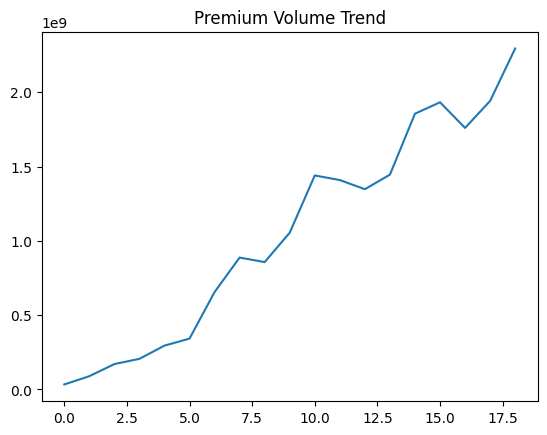

In [72]:
import matplotlib.pyplot as plt

plt.plot(premium_trend["total_premium"])
plt.title("Premium Volume Trend")
plt.show()

Insight 1:
There are ups and downs in the volume of premium. But the trend is still positive.

Business Meaning:
Shows business scaling over time.

## High Volume vs High Value States

In [73]:
state_summary = (
    agg_ins
    .groupby("state", as_index=False)
    .agg(
        total_policies=("insurance_count", "sum"),
        total_premium=("insurance_amount", "sum")
    )
)

state_summary["avg_premium_per_policy"] = (
    state_summary["total_premium"] / state_summary["total_policies"]
)

state_summary.sort_values("total_premium", ascending=False).head()

,state,total_policies,total_premium,avg_premium_per_policy
15,karnataka,1957404,"2,743,154,847","1,401"
20,maharashtra,1815539,"2,363,128,536","1,302"
33,uttar-pradesh,1139153,"1,740,346,495","1,528"
30,tamil-nadu,1215269,"1,555,507,253","1,280"
16,kerala,824235,"1,313,718,507","1,594"


Insight 1:
High avg premium

Business Meaning:
Premium product adoption

## Low Penetration States (Untapped Market)

In [95]:
state_summary["avg_premium"] = (
    state_summary["total_premium"] /
    state_summary["total_premium"]
)

state_summary


,state,total_policies,total_premium,avg_premium_per_policy,avg_premium
0,andaman-&-nicobar-islands,12997,"19,386,792","1,492",1
1,andhra-pradesh,697769,"812,222,985","1,164",1
2,arunachal-pradesh,10214,"23,420,755","2,293",1
3,assam,262818,"411,831,038","1,567",1
4,bihar,536592,"671,056,815","1,251",1
5,chandigarh,22079,"33,285,885","1,508",1
6,chhattisgarh,189517,"274,344,886","1,448",1
7,dadra-&-nagar-haveli-&-daman-&-diu,13792,"17,992,414","1,305",1
8,delhi,652514,"815,365,172","1,250",1
9,goa,59872,"83,730,005","1,398",1


Insight 1:
Punjab ,Jharkhand, Assam, Chattisgarh, Uttarakhand-- These are mid-to-large states but not top contributors.

Business Meaning:
These are better untapped candidates than small UTs.

Strategy:
1.Regional campaigns
2.Local insurer partnerships
3.Rural insurance awareness drives


Insight 2:
Premium Revenue Leaders-- Karnataka, Maharashtra, Tamil Nadu, Uttar Pradesh, Kerala.
South + West India dominate insurance adoption.

Business Meaning:
Strong financial awareness.
Better distribution networks.

## Quarter-on-Quarter (QoQ) Growth

In [96]:
quarterly = (
    agg_ins
    .groupby(["year", "quarter"], as_index=False)
    .agg(total_policies=("insurance_count", "sum"))
)

quarterly 

,year,quarter,total_policies
0,2020,2,185348
1,2020,3,354284
2,2020,4,248626
3,2021,1,318115
4,2021,2,363988
5,2021,3,374860
6,2021,4,526319
7,2022,1,617575
8,2022,2,630744
9,2022,3,806454


In [97]:
quarterly = quarterly.sort_values(["year", "quarter"])

In [98]:
quarterly["qoq_growth"] = (
    quarterly["total_policies"].pct_change() * 100
)

quarterly

,year,quarter,total_policies,qoq_growth
0,2020,2,185348,NaN
1,2020,3,354284,91
2,2020,4,248626,-30
3,2021,1,318115,28
4,2021,2,363988,14
5,2021,3,374860,3
6,2021,4,526319,40
7,2022,1,617575,17
8,2022,2,630744,2
9,2022,3,806454,28


Insight 1:
2020 shows extreme volatility.
2020 Q3--+91%
2020 Q4---30%

Business Meaning:
Due to Covid.

Insight 2:
Strong Expansion Phase (2021–2022)
Multiple 28–40% jumps

Business Meaning:
2021–2022 was the hyper-growth phase.

Insight 3:
Early 2 Quaters (Q1 & Q2) are saturated but recovery happens in Q3 & Q4.

Business Meaning:
This might be due to economic conditions and market correction.

Insight 4:
Stabilization & Scaling (2024)-- Growth is stabilizing around 10–22%,


Business Meaning:
Insurance business moved from hyper-growth to structured scaling phase.

# 3. Transaction Analysis for Market Expansion - Top Transaction


In [1]:
from dotenv import load_dotenv
import os
import mysql.connector
import pandas as pd

# Load environment variables
load_dotenv()

conn = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

query = "SELECT * FROM top_transaction;"
df = pd.read_sql(query, conn)

df.head()

C:\Users\Vigne\AppData\Local\Temp\ipykernel_8068\2651151559.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,state,year,quarter,entity_type,entity_name,transaction_count,transaction_amount
0,1,maharashtra,2023,2,District,pune,554427668,5.358011e+11
1,2,maharashtra,2023,2,District,thane,155714593,1.789394e+11
2,3,maharashtra,2023,2,District,nashik,135966489,1.848671e+11
3,4,maharashtra,2023,2,District,mumbai suburban,130857450,1.484102e+11
4,5,maharashtra,2023,2,District,aurangabad,105820511,1.329529e+11


In [2]:
top_txn = pd.read_sql("SELECT * FROM top_transaction", conn)

print("Data loaded ✅")
print(top_txn.shape)

C:\Users\Vigne\AppData\Local\Temp\ipykernel_8068\763944092.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_txn = pd.read_sql("SELECT * FROM top_transaction", conn)


Data loaded ✅
(18295, 8)


In [14]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [15]:
top_txn.head()

,id,state,year,quarter,entity_type,entity_name,transaction_count,transaction_amount
0,1,maharashtra,2023,2,District,pune,554427668,"535,801,107,518"
1,2,maharashtra,2023,2,District,thane,155714593,"178,939,371,434"
2,3,maharashtra,2023,2,District,nashik,135966489,"184,867,119,659"
3,4,maharashtra,2023,2,District,mumbai suburban,130857450,"148,410,175,880"
4,5,maharashtra,2023,2,District,aurangabad,105820511,"132,952,857,337"


In [10]:
top_txn.columns

Index(['id', 'state', 'year', 'quarter', 'entity_type', 'entity_name',
       'transaction_count', 'transaction_amount'],
      dtype='str')

In [11]:
top_txn.shape

(18295, 8)

In [12]:
top_txn.info()

<class 'pandas.DataFrame'>
RangeIndex: 18295 entries, 0 to 18294
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  18295 non-null  int64  
 1   state               18295 non-null  str    
 2   year                18295 non-null  int64  
 3   quarter             18295 non-null  int64  
 4   entity_type         18295 non-null  str    
 5   entity_name         18295 non-null  str    
 6   transaction_count   18295 non-null  int64  
 7   transaction_amount  18295 non-null  float64
dtypes: float64(1), int64(4), str(3)
memory usage: 1.1 MB


In [16]:
top_txn.describe()

,id,year,quarter,transaction_count,transaction_amount
count,"18,295","18,295","18,295","18,295","18,295"
mean,"9,148","2,021",3,"11,974,674","16,904,436,727"
std,"5,281",2,1,"49,620,898","62,770,092,946"
min,1,"2,018",1,2,60
25%,"4,574","2,019",2,"122,222","237,268,359"
50%,"9,148","2,021",3,"984,522","1,538,456,708"
75%,"13,722","2,023",4,"6,708,908","10,330,932,578"
max,"18,295","2,024",4,"1,674,347,983","1,790,144,192,589"


## Transaction Concentration Risk (Over-Dependence)

STEP 1: Filter Only District-Level Data

In [35]:
district_df = top_txn[top_txn["entity_type"] == "District"].copy()

district_df

,id,state,year,quarter,entity_type,entity_name,transaction_count,transaction_amount
0,1,maharashtra,2023,2,District,pune,554427668,"535,801,107,518"
1,2,maharashtra,2023,2,District,thane,155714593,"178,939,371,434"
2,3,maharashtra,2023,2,District,nashik,135966489,"184,867,119,659"
3,4,maharashtra,2023,2,District,mumbai suburban,130857450,"148,410,175,880"
4,5,maharashtra,2023,2,District,aurangabad,105820511,"132,952,857,337"
...,...,...,...,...,...,...,...,...
18280,18281,tripura,2022,4,District,south tripura,318517,"743,429,833"
18281,18282,tripura,2022,4,District,gomati,303790,"606,245,959"
18282,18283,tripura,2022,4,District,unakoti,292384,"653,255,261"
18283,18284,tripura,2022,4,District,dhalai,289984,"592,125,896"


STEP 2: Calculate Total Transaction Value per District

In [36]:
district_totals = (
    district_df
    .groupby(["state", "entity_name"], as_index=False)
    ["transaction_amount"]
    .sum()
    .rename(columns={"entity_name": "district",
                     "transaction_amount": "district_total"})
)

district_totals.head()

,state,district,district_total
0,andaman-&-nicobar-islands,nicobar,"774,139,214"
1,andaman-&-nicobar-islands,nicobars,"2,522,901,278"
2,andaman-&-nicobar-islands,north and middle andaman,"6,101,006,629"
3,andaman-&-nicobar-islands,south andaman,"61,269,406,025"
4,andhra-pradesh,anantapur,"1,999,312,744,241"


STEP 3: Calculate Total Transaction Value per State

In [37]:
state_totals = (
    district_totals
    .groupby("state", as_index=False)["district_total"]
    .sum()
    .rename(columns={"district_total": "state_total"})
)

state_totals.head()

,state,state_total
0,andaman-&-nicobar-islands,"70,667,453,147"
1,andhra-pradesh,"27,979,944,360,981"
2,arunachal-pradesh,"221,157,970,664"
3,assam,"2,212,331,448,463"
4,bihar,"9,391,455,361,039"


STEP 4: Identify Top 3 Districts per State

In [39]:
district_totals["rank"] = (
    district_totals
    .groupby("state")["district_total"]
    .rank(method="first", ascending=False)
)

top3_districts = district_totals[district_totals["rank"] <= 3]

top3_districts

,state,district,district_total,rank
1,andaman-&-nicobar-islands,nicobars,"2,522,901,278",3
2,andaman-&-nicobar-islands,north and middle andaman,"6,101,006,629",2
3,andaman-&-nicobar-islands,south andaman,"61,269,406,025",1
7,andhra-pradesh,east godavari,"2,975,485,657,270",3
9,andhra-pradesh,guntur,"3,174,526,721,513",2
...,...,...,...,...
390,uttarakhand,haridwar,"436,362,645,283",2
396,uttarakhand,udham singh nagar,"325,604,328,685",3
402,west-bengal,kolkata,"2,655,469,594,201",1
405,west-bengal,murshidabad,"1,236,160,805,304",3


STEP 5: Calculate Top 3 Contribution per State

In [41]:
top3_sum = (
    top3_districts
    .groupby("state", as_index=False)["district_total"]
    .sum()
    .rename(columns={"district_total": "top3_total"})
)

top3_sum

,state,top3_total
0,andaman-&-nicobar-islands,"69,893,313,933"
1,andhra-pradesh,"10,348,580,471,362"
2,arunachal-pradesh,"121,556,505,364"
3,assam,"1,281,705,291,649"
4,bihar,"4,990,995,932,137"
5,chandigarh,"292,906,588,373"
6,chhattisgarh,"2,079,351,442,785"
7,dadra-&-nagar-haveli-&-daman-&-diu,"201,719,857,192"
8,delhi,"5,750,581,217,060"
9,goa,"511,021,161,407"


STEP 6: Merge With State Totals & Calculate %

In [44]:
concentration_df = pd.merge(
    state_totals,
    top3_sum,
    on="state",
    how="left"
)

concentration_df["concentration_pct"] = (
    concentration_df["top3_total"] /
    concentration_df["state_total"]
) * 100

concentration_df = concentration_df.sort_values(
    by="concentration_pct",
    ascending=False
)

concentration_df.head(20)

,state,state_total,top3_total,concentration_pct
18,lakshadweep,"1,609,320,785","1,609,320,785",100
9,goa,"511,021,161,407","511,021,161,407",100
7,dadra-&-nagar-haveli-&-daman-&-diu,"201,719,857,192","201,719,857,192",100
5,chandigarh,"292,906,588,373","292,906,588,373",100
17,ladakh,"88,994,622,100","88,994,622,100",100
0,andaman-&-nicobar-islands,"70,667,453,147","69,893,313,933",99
26,puducherry,"237,317,074,404","232,258,216,358",98
24,nagaland,"128,464,847,852","100,412,605,569",78
34,uttarakhand,"1,861,775,742,738","1,453,592,504,143",78
21,manipur,"175,705,292,179","135,483,191,071",77


Insight 1: Analysis revealed that large states such as Karnataka and Telangana exhibit high transaction concentration in top metro districts, contributing over 70% of total state transaction value. This indicates revenue dependency risk and highlights expansion potential in Tier-2 and Tier-3 districts to improve geographic diversification.

Business Meaning: 
1.Revenue is heavily dependent on metro districts.
2.Digital adoption is concentrated in urban clusters.
3.Growth outside top cities is underdeveloped.


## Hidden High-Performing Districts in Mid-Level States

STEP 1: Identify Top 5 States by Total Transaction Value

In [45]:
import pandas as pd

# Aggregate total transaction value per state
state_totals = (
    df.groupby("state")["transaction_amount"]
      .sum()
      .sort_values(ascending=False)
)

# Get top 5 states
top_5_states = state_totals.head(5).index.tolist()

print("Top 5 States:", top_5_states)

Top 5 States: ['telangana', 'karnataka', 'maharashtra', 'andhra-pradesh', 'uttar-pradesh']


STEP 2: Create Yearly District-Level Aggregation

In [46]:
district_df = top_txn[top_txn["entity_type"] == "District"]

# Aggregate yearly transaction value per district
district_yearly = (
    district_df
    .groupby(["state", "entity_name", "year"], as_index=False)
    ["transaction_amount"]
    .sum()
    .rename(columns={"entity_name": "district",
                     "transaction_amount": "yearly_value"})
)

district_yearly.head()

,state,district,year,yearly_value
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214"
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974"
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293"
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377"
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674"


STEP 3: Calculate YoY Growth for Each District

In [48]:
# Sort for proper growth calculation
district_yearly = district_yearly.sort_values(
    by=["state", "district", "year"]
)

# Calculate previous year value
district_yearly["prev_year_value"] = (
    district_yearly
    .groupby(["state", "district"])["yearly_value"]
    .shift(1)
)

# Calculate YoY growth %
district_yearly["yoy_growth"] = (
    (district_yearly["yearly_value"] - district_yearly["prev_year_value"])
    / district_yearly["prev_year_value"]
) * 100

district_yearly

,state,district,year,yearly_value,prev_year_value,yoy_growth
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214",NaN,NaN
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974",NaN,NaN
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293","17,780,974",127
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377","40,298,293",108
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674","83,826,377",190
...,...,...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668","7,625,290,598",277
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870","28,710,873,668",127
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632","65,068,849,870",90
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078","123,680,565,632",131


STEP 4: Exclude Top 5 States

In [50]:
hidden_states_df = district_yearly[
    ~district_yearly["state"].isin(top_5_states)
]

hidden_states_df

,state,district,year,yearly_value,prev_year_value,yoy_growth
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214",NaN,NaN
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974",NaN,NaN
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293","17,780,974",127
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377","40,298,293",108
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674","83,826,377",190
...,...,...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668","7,625,290,598",277
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870","28,710,873,668",127
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632","65,068,849,870",90
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078","123,680,565,632",131


STEP 5: Remove Fake Growth (Low Base Effect)

In [52]:
# Filter meaningful transaction size
filtered_growth = hidden_states_df[
    (hidden_states_df["yearly_value"] > 1e8) &   # adjust threshold
    (hidden_states_df["prev_year_value"] > 1e8)
]

filtered_growth

,state,district,year,yearly_value,prev_year_value,yoy_growth
5,andaman-&-nicobar-islands,nicobars,2022,"501,001,002","243,405,674",106
6,andaman-&-nicobar-islands,nicobars,2023,"997,555,237","501,001,002",99
7,andaman-&-nicobar-islands,nicobars,2024,"639,033,721","997,555,237",-36
11,andaman-&-nicobar-islands,north and middle andaman,2021,"440,001,622","139,573,291",215
12,andaman-&-nicobar-islands,north and middle andaman,2022,"810,331,301","440,001,622",84
...,...,...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668","7,625,290,598",277
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870","28,710,873,668",127
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632","65,068,849,870",90
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078","123,680,565,632",131


STEP 6: Get Top 20 Hidden High-Growth Districts

In [53]:
top_hidden_districts = (
    filtered_growth
    .sort_values(by="yoy_growth", ascending=False)
    .dropna(subset=["yoy_growth"])
    .head(20)
)

top_hidden_districts

,state,district,year,yearly_value,prev_year_value,yoy_growth
878,jharkhand,koderma,2021,"12,466,689,148","382,615,732","3,158"
200,assam,dhubri,2021,"5,452,127,412","168,832,531","3,129"
2183,west-bengal,maldah,2022,"26,922,829,612","876,762,579","2,971"
259,bihar,bhagalpur,2020,"17,108,975,964","579,615,298","2,852"
629,haryana,jhajjar,2023,"108,174,446,875","5,544,973,431","1,851"
1749,rajasthan,nagaur,2020,"26,683,795,980","1,372,225,292","1,845"
1084,madhya-pradesh,chhindwara,2022,"614,331,585,581","33,512,376,273","1,733"
2169,west-bengal,howrah,2020,"28,437,396,773","2,186,684,125","1,200"
1717,rajasthan,bikaner,2022,"106,931,762,352","8,393,453,473","1,174"
455,delhi,new delhi,2019,"147,772,629,183","12,439,385,039","1,088"


Insight 1: Unexpected Growth Hubs in Non-Metro Regions
Koderma (Jharkhand – 3158)
Dhubri (Assam – 3129)
Maldah (West Bengal – 2971)
Bhagalpur (Bihar – 2852)

Business Meaning: These are Tier-3 / semi-urban districts showing disproportionately high digital transaction activity.

Insight 2: Haryana Appears Multiple Times in result

Business Meaning: Haryana is becoming a distributed digital commerce zone.

Insight 3: State-Level Strategy Should Be District-Specific
Instead of: “Jharkhand is a weak market”
The data says: “Koderma in Jharkhand is extremely strong”

Business Meaning: So strategy must shift from state-level targeting → district-level targeting.

## Emerging Tier-2 / Tier-3 Markets

STEP 1 — Filter Only District Data

In [61]:
district_df = top_txn[top_txn['entity_type'] == 'District'].copy()

district_df 


,id,state,year,quarter,entity_type,entity_name,transaction_count,transaction_amount
0,1,maharashtra,2023,2,District,pune,554427668,"535,801,107,518"
1,2,maharashtra,2023,2,District,thane,155714593,"178,939,371,434"
2,3,maharashtra,2023,2,District,nashik,135966489,"184,867,119,659"
3,4,maharashtra,2023,2,District,mumbai suburban,130857450,"148,410,175,880"
4,5,maharashtra,2023,2,District,aurangabad,105820511,"132,952,857,337"
...,...,...,...,...,...,...,...,...
18280,18281,tripura,2022,4,District,south tripura,318517,"743,429,833"
18281,18282,tripura,2022,4,District,gomati,303790,"606,245,959"
18282,18283,tripura,2022,4,District,unakoti,292384,"653,255,261"
18283,18284,tripura,2022,4,District,dhalai,289984,"592,125,896"


STEP 2 — Aggregate Yearly Transaction Amount

In [63]:
district_year = (
    district_df.groupby(['state','entity_name','year'], as_index=False)
    .agg({'transaction_amount':'sum'})
)

district_year

,state,entity_name,year,transaction_amount
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214"
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974"
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293"
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377"
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674"
...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668"
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870"
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632"
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078"


STEP 3 — Sort Properly

In [65]:
district_year = district_year.sort_values(
    ['state','entity_name','year']
)

district_year

,state,entity_name,year,transaction_amount
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214"
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974"
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293"
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377"
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674"
...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668"
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870"
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632"
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078"


STEP 4 — Calculate YoY Growth

In [67]:
district_year['yoy_growth'] = (
    district_year
    .groupby(['state','entity_name'])['transaction_amount']
    .pct_change() * 100
)

district_year

,state,entity_name,year,transaction_amount,yoy_growth
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214",NaN
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974",NaN
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293",127
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377",108
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674",190
...,...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668",277
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870",127
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632",90
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078",131


STEP 5 — Take Latest Year

In [68]:
latest_year = district_year['year'].max()

latest = district_year[
    district_year['year'] == latest_year
].copy()

latest_year

np.int64(2024)

STEP 6 — Remove Big Metro Districts (Simple Logic)

In [69]:
latest = latest.sort_values(
    by='transaction_amount',
    ascending=False
)

# remove top 20
latest = latest.iloc[20:]

STEP 7 — Get Fastest Growing Mid-Level Markets

In [70]:
emerging = latest.sort_values(
    by='yoy_growth',
    ascending=False
)

emerging.head(15)

,state,entity_name,year,transaction_amount,yoy_growth
1136,madhya-pradesh,sagar,2024,"85,825,378,345",615
2184,west-bengal,maldah,2024,"167,148,091,490",521
1719,rajasthan,bikaner,2024,"318,830,183,384",498
807,jammu-&-kashmir,rajouri,2024,"7,559,341,893",450
187,assam,bongaigaon,2024,"49,106,882,689",409
671,haryana,rohtak,2024,"69,232,843,144",185
1264,manipur,jiribam,2024,"1,479,813,212",174
1281,manipur,senapati,2024,"1,435,328,799",130
1308,manipur,ukhrul,2024,"1,462,765,329",125
1301,manipur,thoubal,2024,"4,581,257,039",120


Insight 1: Manipur Cluster Effect (Multiple Districts Growing Together)
Jiribam, Senapati, Ukhrul, Thoubal, Bishnupur, Churachandpur --

Business Meaning: This is NOT district-level randomness.
This is State-wide digital acceleration wave.

Insight 2: Several non-metro districts across Madhya Pradesh, West Bengal, Rajasthan, Jammu & Kashmir, Assam, and Manipur are experiencing 90%–600% YoY growth in digital transactions. These markets represent early-stage digital adoption zones and offer high ROI expansion opportunities before saturation and competitive entry.

## Average Transaction Value Variation (Spending Behavior)

STEP 1 — Filter Only District Data

In [72]:
district_df = top_txn[top_txn['entity_type'] == 'District'].copy()

district_df

,id,state,year,quarter,entity_type,entity_name,transaction_count,transaction_amount
0,1,maharashtra,2023,2,District,pune,554427668,"535,801,107,518"
1,2,maharashtra,2023,2,District,thane,155714593,"178,939,371,434"
2,3,maharashtra,2023,2,District,nashik,135966489,"184,867,119,659"
3,4,maharashtra,2023,2,District,mumbai suburban,130857450,"148,410,175,880"
4,5,maharashtra,2023,2,District,aurangabad,105820511,"132,952,857,337"
...,...,...,...,...,...,...,...,...
18280,18281,tripura,2022,4,District,south tripura,318517,"743,429,833"
18281,18282,tripura,2022,4,District,gomati,303790,"606,245,959"
18282,18283,tripura,2022,4,District,unakoti,292384,"653,255,261"
18283,18284,tripura,2022,4,District,dhalai,289984,"592,125,896"


STEP 2 — Aggregate Yearly District Data

In [74]:
district_year = (
    district_df.groupby(['state','entity_name','year'], as_index=False)
    .agg({
        'transaction_amount': 'sum',
        'transaction_count': 'sum'
    })
)

district_year

,state,entity_name,year,transaction_amount,transaction_count
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214",443356
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974",4604
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293",8267
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377",20907
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674",70800
...,...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668",16983144
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870",30405525
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632",54896711
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078",146175999


STEP 3 — Calculate Average Transaction Value

In [76]:
district_year['avg_transaction_value'] = (
    district_year['transaction_amount'] /
    district_year['transaction_count']
)

district_year

,state,entity_name,year,transaction_amount,transaction_count,avg_transaction_value
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214",443356,"1,746"
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974",4604,"3,862"
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293",8267,"4,875"
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377",20907,"4,009"
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674",70800,"3,438"
...,...,...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668",16983144,"1,691"
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870",30405525,"2,140"
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632",54896711,"2,253"
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078",146175999,"1,952"


STEP 4 — Focus on Latest Year

In [77]:
latest_year = district_year['year'].max()

latest = district_year[
    district_year['year'] == latest_year
].copy()

latest_year

np.int64(2024)

STEP 5 — Sort by Average Transaction Value

In [ ]:
#High Average (Premium Behavior)

high_avg = latest.sort_values(
    by='avg_transaction_value',
    ascending=False
)

high_avg.head(10)

high_avg

,state,entity_name,year,transaction_amount,transaction_count,avg_transaction_value
1429,mizoram,saiha,2024,"301,794,799",104892,"2,877"
1452,nagaland,kiphire,2024,"295,733,044",107110,"2,761"
1308,manipur,ukhrul,2024,"1,462,765,329",543814,"2,690"
1294,manipur,tengnoupal,2024,"306,617,325",118339,"2,591"
1491,nagaland,phek,2024,"1,288,183,085",513336,"2,509"
...,...,...,...,...,...,...
425,dadra-&-nagar-haveli-&-daman-&-diu,dadra and nagar haveli,2024,"55,223,273,389",63547660,869
2027,uttar-pradesh,gautam buddha nagar,2024,"410,748,490,016",480316935,855
742,himachal-pradesh,solan,2024,"41,674,314,435",50007632,833
432,dadra-&-nagar-haveli-&-daman-&-diu,daman,2024,"27,630,894,223",33157372,833


In [ ]:
#Low Average (Micro-Transaction Heavy)

low_avg = latest.sort_values(
    by='avg_transaction_value',
    ascending=True
)

low_avg.head(10)

,state,entity_name,year,transaction_amount,transaction_count,avg_transaction_value
2028,uttar-pradesh,gautambuddha nagar,2024,"492,018,229,608",599893136,820
432,dadra-&-nagar-haveli-&-daman-&-diu,daman,2024,"27,630,894,223",33157372,833
742,himachal-pradesh,solan,2024,"41,674,314,435",50007632,833
2027,uttar-pradesh,gautam buddha nagar,2024,"410,748,490,016",480316935,855
425,dadra-&-nagar-haveli-&-daman-&-diu,dadra and nagar haveli,2024,"55,223,273,389",63547660,869
618,haryana,gurugram,2024,"955,435,958,504",1080565624,884
1205,maharashtra,pune,2024,"2,955,231,337,091",3248024395,910
491,delhi,south,2024,"235,119,732,561",248553741,946
492,delhi,south east,2024,"241,867,580,049",248871701,972
1081,madhya-pradesh,bhopal,2024,"636,857,359,907",641949458,992


Insight 1: High Average Transaction Value Districts (~₹2500–₹2800)
Saiha, Kiphire, Ukhrul, Phek

Avg Value: ₹2500–₹2800
Transaction volume: Relatively low

Insight 2: Low Average Transaction Value Districts (~₹820–₹990)
Gurugram, Pune, Bhopal, South Delhi, Gautam Buddha Nagar

Avg Value: ₹820–₹990
Transaction volume: Extremely high

The Surprising Insight:

Most people assume:

Urban = higher ticket size
Rural = lower ticket size

our data shows the opposite.

Business Meaning: 
Urban Districts (Low Avg Value)-----------Urban areas = Micro-transaction economy------It also means Daily digital lifestyle economy.

Example: Pune → ₹2.95 trillion amount
         3.24 billion transactions
         Avg ~ ₹910
Behavior: High frequency, small ticket.
Strategy:
 Cashback campaigns
 Subscription payments
 Merchant QR expansion
 UPI rewards
 Consumer loyalty programs

Small / North-East Districts (High Avg Value)------More concentrated transaction types--------- Emerging but concentrated transaction economy.

Example: Saiha → ₹301M amount
         104k transactions
         Avg ~ ₹2877
Behavior: Low frequency, higher ticket.
Strategy:
 Credit products
 EMI financing
 Micro-business loans
 Insurance
 Agri or MSME lending         

Final Conclusion: India’s digital growth is volume-driven in metros, but value-driven in smaller regions.

## District Growth vs State Growth Gap

STEP 1 — Filter District Data

In [80]:
district_df = top_txn[top_txn['entity_type'] == 'District'].copy()

district_df

,id,state,year,quarter,entity_type,entity_name,transaction_count,transaction_amount
0,1,maharashtra,2023,2,District,pune,554427668,"535,801,107,518"
1,2,maharashtra,2023,2,District,thane,155714593,"178,939,371,434"
2,3,maharashtra,2023,2,District,nashik,135966489,"184,867,119,659"
3,4,maharashtra,2023,2,District,mumbai suburban,130857450,"148,410,175,880"
4,5,maharashtra,2023,2,District,aurangabad,105820511,"132,952,857,337"
...,...,...,...,...,...,...,...,...
18280,18281,tripura,2022,4,District,south tripura,318517,"743,429,833"
18281,18282,tripura,2022,4,District,gomati,303790,"606,245,959"
18282,18283,tripura,2022,4,District,unakoti,292384,"653,255,261"
18283,18284,tripura,2022,4,District,dhalai,289984,"592,125,896"


STEP 2 — Calculate District Yearly Total

In [84]:
district_year = (
    district_df
    .groupby(['state','entity_name','year'], as_index=False)
    .agg({'transaction_amount':'sum'})
)

district_year

,state,entity_name,year,transaction_amount
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214"
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974"
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293"
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377"
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674"
...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668"
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870"
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632"
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078"


In [85]:
# sort
district_year = district_year.sort_values(
    ['state','entity_name','year']
)

district_year

,state,entity_name,year,transaction_amount
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214"
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974"
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293"
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377"
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674"
...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668"
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870"
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632"
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078"


STEP 3 — Calculate District YoY Growth

In [87]:
district_year['district_yoy_growth'] = (
    district_year
    .groupby(['state','entity_name'])['transaction_amount']
    .pct_change() * 100
)

district_year

,state,entity_name,year,transaction_amount,district_yoy_growth
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214",NaN
1,andaman-&-nicobar-islands,nicobars,2018,"17,780,974",NaN
2,andaman-&-nicobar-islands,nicobars,2019,"40,298,293",127
3,andaman-&-nicobar-islands,nicobars,2020,"83,826,377",108
4,andaman-&-nicobar-islands,nicobars,2021,"243,405,674",190
...,...,...,...,...,...
2232,west-bengal,south twenty four parganas,2020,"28,710,873,668",277
2233,west-bengal,south twenty four parganas,2021,"65,068,849,870",127
2234,west-bengal,south twenty four parganas,2022,"123,680,565,632",90
2235,west-bengal,south twenty four parganas,2023,"285,307,078,078",131


STEP 4 — Calculate State Yearly Total

In [88]:
state_year = (
    district_df
    .groupby(['state','year'], as_index=False)
    .agg({'transaction_amount':'sum'})
)

state_year

,state,year,transaction_amount
0,andaman-&-nicobar-islands,2018,"189,076,104"
1,andaman-&-nicobar-islands,2019,"473,464,757"
2,andaman-&-nicobar-islands,2020,"1,296,423,416"
3,andaman-&-nicobar-islands,2021,"4,925,488,081"
4,andaman-&-nicobar-islands,2022,"12,110,256,729"
...,...,...,...
247,west-bengal,2020,"434,822,380,495"
248,west-bengal,2021,"1,078,486,016,989"
249,west-bengal,2022,"2,130,453,715,217"
250,west-bengal,2023,"3,085,711,436,480"


In [90]:
# sort
state_year = state_year.sort_values(['state','year'])

state_year

,state,year,transaction_amount
0,andaman-&-nicobar-islands,2018,"189,076,104"
1,andaman-&-nicobar-islands,2019,"473,464,757"
2,andaman-&-nicobar-islands,2020,"1,296,423,416"
3,andaman-&-nicobar-islands,2021,"4,925,488,081"
4,andaman-&-nicobar-islands,2022,"12,110,256,729"
...,...,...,...
247,west-bengal,2020,"434,822,380,495"
248,west-bengal,2021,"1,078,486,016,989"
249,west-bengal,2022,"2,130,453,715,217"
250,west-bengal,2023,"3,085,711,436,480"


STEP 5 — Calculate State YoY Growth

In [92]:
state_year['state_yoy_growth'] = (
    state_year
    .groupby('state')['transaction_amount']
    .pct_change() * 100
)

state_year

,state,year,transaction_amount,state_yoy_growth
0,andaman-&-nicobar-islands,2018,"189,076,104",NaN
1,andaman-&-nicobar-islands,2019,"473,464,757",150
2,andaman-&-nicobar-islands,2020,"1,296,423,416",174
3,andaman-&-nicobar-islands,2021,"4,925,488,081",280
4,andaman-&-nicobar-islands,2022,"12,110,256,729",146
...,...,...,...,...
247,west-bengal,2020,"434,822,380,495",109
248,west-bengal,2021,"1,078,486,016,989",148
249,west-bengal,2022,"2,130,453,715,217",98
250,west-bengal,2023,"3,085,711,436,480",45


STEP 6 — Take Latest Year Only

In [94]:
latest_year = district_year['year'].max()

district_latest = district_year[
    district_year['year'] == latest_year
].copy()

state_latest = state_year[
    state_year['year'] == latest_year
].copy()

latest_year

np.int64(2024)

STEP 7 — Merge District & State Growth

In [96]:
growth_gap = district_latest.merge(
    state_latest[['state','state_yoy_growth']],
    on='state',
    how='left'
)

growth_gap

,state,entity_name,year,transaction_amount,district_yoy_growth,state_yoy_growth
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214",NaN,47
1,andaman-&-nicobar-islands,nicobars,2024,"639,033,721",-36,47
2,andaman-&-nicobar-islands,north and middle andaman,2024,"2,761,936,720",46,47
3,andaman-&-nicobar-islands,south andaman,2024,"26,564,612,292",47,47
4,andhra-pradesh,anantapur,2024,"438,405,569,654",-41,2
...,...,...,...,...,...,...
338,west-bengal,nadia,2024,"365,853,552,625",60,52
339,west-bengal,north twenty four parganas,2024,"914,964,346,396",43,52
340,west-bengal,paschim medinipur,2024,"303,022,079,009",50,52
341,west-bengal,purba medinipur,2024,"406,387,947,731",49,52


STEP 8 — Calculate Growth Gap

In [97]:
growth_gap['growth_gap'] = (
    growth_gap['district_yoy_growth'] -
    growth_gap['state_yoy_growth']
)

growth_gap

,state,entity_name,year,transaction_amount,district_yoy_growth,state_yoy_growth,growth_gap
0,andaman-&-nicobar-islands,nicobar,2024,"774,139,214",NaN,47,NaN
1,andaman-&-nicobar-islands,nicobars,2024,"639,033,721",-36,47,-83
2,andaman-&-nicobar-islands,north and middle andaman,2024,"2,761,936,720",46,47,-1
3,andaman-&-nicobar-islands,south andaman,2024,"26,564,612,292",47,47,0
4,andhra-pradesh,anantapur,2024,"438,405,569,654",-41,2,-42
...,...,...,...,...,...,...,...
338,west-bengal,nadia,2024,"365,853,552,625",60,52,8
339,west-bengal,north twenty four parganas,2024,"914,964,346,396",43,52,-9
340,west-bengal,paschim medinipur,2024,"303,022,079,009",50,52,-2
341,west-bengal,purba medinipur,2024,"406,387,947,731",49,52,-3


STEP 9 — Find Breakout Districts

In [98]:
breakout = growth_gap.sort_values(
    by='growth_gap',
    ascending=False
)

breakout.head(15)

,state,entity_name,year,transaction_amount,district_yoy_growth,state_yoy_growth,growth_gap
171,madhya-pradesh,sagar,2024,"85,825,378,345",615,42,574
261,rajasthan,bikaner,2024,"318,830,183,384",498,23,475
336,west-bengal,maldah,2024,"167,148,091,490",521,52,469
123,jammu-&-kashmir,rajouri,2024,"7,559,341,893",450,66,383
32,assam,bongaigaon,2024,"49,106,882,689",409,40,369
104,haryana,rohtak,2024,"69,232,843,144",185,38,148
189,manipur,jiribam,2024,"1,479,813,212",174,86,88
148,karnataka,vijayapura,2024,"339,278,492,180",91,29,62
143,karnataka,hassan,2024,"96,932,033,734",87,29,58
128,jharkhand,deoghar,2024,"88,439,154,181",100,43,57


Insight 1: Several districts across Madhya Pradesh, Rajasthan, West Bengal, Assam, and Jammu & Kashmir are growing 300%–600% faster than their respective state averages. These districts represent breakout digital economies and should be prioritized for hyperlocal expansion strategies, merchant credit deployment, and targeted marketing campaigns.

Business Meaning:

Growth in India is hyperlocal, not uniform.

State-level strategy is too broad.
--Within the same state: One district grows 40%
                         Another grows 600%

If you invest at state level blindly, you waste capital.

Instead companies should invest at district level.                         

# 4. Insurance Engagement Analysis - Map Insurance

In [8]:
from dotenv import load_dotenv
import os
import mysql.connector
import pandas as pd

# Load environment variables
load_dotenv()

conn = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

query = "SELECT * FROM top_insurance;"
df = pd.read_sql(query, conn)

df.head()

C:\Users\Vigne\AppData\Local\Temp\ipykernel_6728\820682050.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,state,year,quarter,entity_type,entity_name,insurance_count,insurance_amount
0,1,maharashtra,2023,2,District,pune,25943,"39,373,541"
1,2,maharashtra,2023,2,District,thane,15403,"20,442,020"
2,3,maharashtra,2023,2,District,mumbai suburban,12717,"15,575,502"
3,4,maharashtra,2023,2,District,nagpur,6951,"10,373,645"
4,5,maharashtra,2023,2,District,mumbai,4859,"6,032,079"


In [9]:
top_ins = pd.read_sql("SELECT * FROM top_insurance", conn)

print("Data loaded ✅")
print(top_ins.shape)

Data loaded ✅
(12276, 8)


C:\Users\Vigne\AppData\Local\Temp\ipykernel_6728\181158483.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_ins = pd.read_sql("SELECT * FROM top_insurance", conn)


In [10]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [11]:
top_ins.head()

,id,state,year,quarter,entity_type,entity_name,insurance_count,insurance_amount
0,1,maharashtra,2023,2,District,pune,25943,"39,373,541"
1,2,maharashtra,2023,2,District,thane,15403,"20,442,020"
2,3,maharashtra,2023,2,District,mumbai suburban,12717,"15,575,502"
3,4,maharashtra,2023,2,District,nagpur,6951,"10,373,645"
4,5,maharashtra,2023,2,District,mumbai,4859,"6,032,079"


In [12]:
top_ins.columns

Index(['id', 'state', 'year', 'quarter', 'entity_type', 'entity_name',
       'insurance_count', 'insurance_amount'],
      dtype='str')

In [13]:
top_ins.shape

(12276, 8)

In [14]:
top_ins.info()

<class 'pandas.DataFrame'>
RangeIndex: 12276 entries, 0 to 12275
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                12276 non-null  int64  
 1   state             12276 non-null  str    
 2   year              12276 non-null  int64  
 3   quarter           12276 non-null  int64  
 4   entity_type       12276 non-null  str    
 5   entity_name       12276 non-null  str    
 6   insurance_count   12276 non-null  int64  
 7   insurance_amount  12276 non-null  float64
dtypes: float64(1), int64(4), str(3)
memory usage: 767.4 KB


In [15]:
top_ins.describe()

,id,year,quarter,insurance_count,insurance_amount
count,"12,276","12,276","12,276","12,276","12,276"
mean,"6,138","2,022",3,"1,091","1,457,266"
std,"3,544",1,1,"3,326","4,781,771"
min,1,"2,020",1,1,31
25%,"3,070","2,021",2,50,"55,934"
50%,"6,138","2,022",3,282,"302,106"
75%,"9,207","2,023",4,968,"1,222,880"
max,"12,276","2,024",4,"96,935","159,224,823"


## Growth Analysis (Very Important)

Step 1: Aggregate State-Year Data

In [128]:
state_year = (
    df.groupby(["state", "year"], as_index=False)
      .agg({
          "insurance_count": "sum",
          "insurance_amount": "sum"
      })
)

state_year

,state,year,insurance_count,insurance_amount
0,andaman-&-nicobar-islands,2020,330,"339,060"
1,andaman-&-nicobar-islands,2021,2569,"3,359,770"
2,andaman-&-nicobar-islands,2022,5316,"7,900,642"
3,andaman-&-nicobar-islands,2023,7034,"10,615,000"
4,andaman-&-nicobar-islands,2024,9339,"13,998,753"
...,...,...,...,...
175,west-bengal,2020,26829,"10,297,399"
176,west-bengal,2021,76146,"65,639,035"
177,west-bengal,2022,149178,"186,080,093"
178,west-bengal,2023,206095,"272,508,547"


Step 2: Sort Properly

In [130]:
state_year = state_year.sort_values(["state", "year"])

state_year

,state,year,insurance_count,insurance_amount
0,andaman-&-nicobar-islands,2020,330,"339,060"
1,andaman-&-nicobar-islands,2021,2569,"3,359,770"
2,andaman-&-nicobar-islands,2022,5316,"7,900,642"
3,andaman-&-nicobar-islands,2023,7034,"10,615,000"
4,andaman-&-nicobar-islands,2024,9339,"13,998,753"
...,...,...,...,...
175,west-bengal,2020,26829,"10,297,399"
176,west-bengal,2021,76146,"65,639,035"
177,west-bengal,2022,149178,"186,080,093"
178,west-bengal,2023,206095,"272,508,547"


Step 3: Calculate YoY Growth

In [131]:
state_year["yoy_growth_%"] = (
    state_year.groupby("state")["insurance_count"]
              .pct_change() * 100
)

state_year

,state,year,insurance_count,insurance_amount,yoy_growth_%
0,andaman-&-nicobar-islands,2020,330,"339,060",NaN
1,andaman-&-nicobar-islands,2021,2569,"3,359,770",678
2,andaman-&-nicobar-islands,2022,5316,"7,900,642",107
3,andaman-&-nicobar-islands,2023,7034,"10,615,000",32
4,andaman-&-nicobar-islands,2024,9339,"13,998,753",33
...,...,...,...,...,...
175,west-bengal,2020,26829,"10,297,399",NaN
176,west-bengal,2021,76146,"65,639,035",184
177,west-bengal,2022,149178,"186,080,093",96
178,west-bengal,2023,206095,"272,508,547",38


Step 4: Remove First Year (NaN Growth)

In [132]:
state_growth = state_year.dropna(subset=["yoy_growth_%"])

state_growth

,state,year,insurance_count,insurance_amount,yoy_growth_%
1,andaman-&-nicobar-islands,2021,2569,"3,359,770",678
2,andaman-&-nicobar-islands,2022,5316,"7,900,642",107
3,andaman-&-nicobar-islands,2023,7034,"10,615,000",32
4,andaman-&-nicobar-islands,2024,9339,"13,998,753",33
6,andhra-pradesh,2021,104926,"86,002,566",11
...,...,...,...,...,...
174,uttarakhand,2024,61670,"105,510,328",35
176,west-bengal,2021,76146,"65,639,035",184
177,west-bengal,2022,149178,"186,080,093",96
178,west-bengal,2023,206095,"272,508,547",38


Step 5: Find Fastest Growing States

In [133]:
fastest_growing_states = state_growth.sort_values(
    by="yoy_growth_%",
    ascending=False
)

fastest_growing_states.head(10)

,state,year,insurance_count,insurance_amount,yoy_growth_%
91,lakshadweep,2021,78,"90,634",875
1,andaman-&-nicobar-islands,2021,2569,"3,359,770",678
66,jammu-&-kashmir,2021,8014,"11,067,170",442
86,ladakh,2021,686,"976,819",364
82,kerala,2022,182481,"289,754,590",321
116,mizoram,2021,1485,"1,258,710",318
131,puducherry,2021,3806,"3,890,503",300
171,uttarakhand,2021,20944,"24,749,722",291
61,himachal-pradesh,2021,8330,"11,140,592",281
151,tamil-nadu,2021,71144,"72,335,467",263


Step 6: More Realistic Insight (Multi-Year Average Growth)

In [134]:
avg_growth = (
    state_growth.groupby("state", as_index=False)
                .agg({
                    "yoy_growth_%": "mean",
                    "insurance_count": "sum"
                })
)

avg_growth = avg_growth.sort_values(
    by="yoy_growth_%",
    ascending=False
)

avg_growth.head(10)

,state,yoy_growth_%,insurance_count
18,lakshadweep,292,984
0,andaman-&-nicobar-islands,213,24258
13,jammu-&-kashmir,158,79650
17,ladakh,140,6356
16,kerala,138,765827
30,tamil-nadu,137,998492
26,puducherry,133,45752
3,assam,116,192170
32,tripura,116,35045
22,meghalaya,113,15703


Step 7: Identify True Emerging Markets

In [135]:
volume_threshold = avg_growth["insurance_count"].quantile(0.6)

emerging_markets = avg_growth[
    (avg_growth["yoy_growth_%"] > 30) &  # high growth
    (avg_growth["insurance_count"] < volume_threshold)  # not already saturated
]

emerging_markets.sort_values(
    by="yoy_growth_%",
    ascending=False
).head(10)

,state,yoy_growth_%,insurance_count
18,lakshadweep,292,984
0,andaman-&-nicobar-islands,213,24258
13,jammu-&-kashmir,158,79650
17,ladakh,140,6356
26,puducherry,133,45752
3,assam,116,192170
32,tripura,116,35045
22,meghalaya,113,15703
12,himachal-pradesh,111,75950
9,goa,108,84092


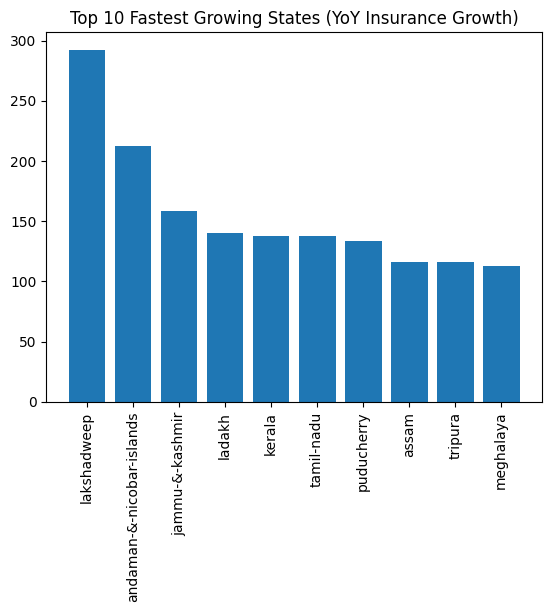

In [136]:
import matplotlib.pyplot as plt

top10_growth = avg_growth.head(10)

plt.figure()
plt.bar(top10_growth["state"], top10_growth["yoy_growth_%"])
plt.xticks(rotation=90)
plt.title("Top 10 Fastest Growing States (YoY Insurance Growth)")
plt.show()

Insight 1:
Emerging Strong Markets (Best Targets)
Jammu & Kashmir, Assam, Himachal Pradesh, Puducherry, Goa

Business Meaning:
Showing High growth and moderate volume.

Strategy: These are your true emerging insurance markets.
        1.Regional partnerships
        2.Awareness campaigns

Insight 2:
High Volume + High Growth (Powerhouse States)
Kerala, Tamil Nadu

Business Meaning:
Showing High growth and strong volume.
These are NOT emerging — they are accelerating mature markets.
        1.Digital maturity high
        2.Users comfortable buying insurance via app

Strategy: Scale premium insurance in Kerala and Tamilnadu.        

## District-Level Concentration

Step 1: District-Level Aggregation

In [20]:
import pandas as pd
df.head()


,id,state,year,quarter,entity_type,entity_name,insurance_count,insurance_amount
0,1,maharashtra,2023,2,District,pune,25943,"39,373,541"
1,2,maharashtra,2023,2,District,thane,15403,"20,442,020"
2,3,maharashtra,2023,2,District,mumbai suburban,12717,"15,575,502"
3,4,maharashtra,2023,2,District,nagpur,6951,"10,373,645"
4,5,maharashtra,2023,2,District,mumbai,4859,"6,032,079"


In [24]:
df_dist = df.groupby(['state', 'entity_name'])['insurance_count'].sum().reset_index()

df_dist

,state,entity_name,insurance_count
0,andaman-&-nicobar-islands,744101,1991
1,andaman-&-nicobar-islands,744102,1499
2,andaman-&-nicobar-islands,744103,3071
3,andaman-&-nicobar-islands,744104,625
4,andaman-&-nicobar-islands,744105,2291
...,...,...,...
1312,west-bengal,paschim bardhaman,46412
1313,west-bengal,paschim medinipur,34318
1314,west-bengal,purba bardhaman,17139
1315,west-bengal,purba medinipur,5145


Step:2 Top 10 districts

In [25]:
top10 = df_dist.sort_values(by='insurance_count', ascending=False).head(10)

print(top10)

            state         entity_name  insurance_count
559     karnataka     bengaluru urban          1117691
711   maharashtra                pune           396173
714   maharashtra               thane           260578
1109   tamil-nadu             chennai           251081
707   maharashtra     mumbai suburban           211311
1151    telangana          rangareddy           206714
1146    telangana  medchal malkajgiri           178028
1035    rajasthan              jaipur           177296
1142    telangana           hyderabad           169470
394       haryana            gurugram           168368


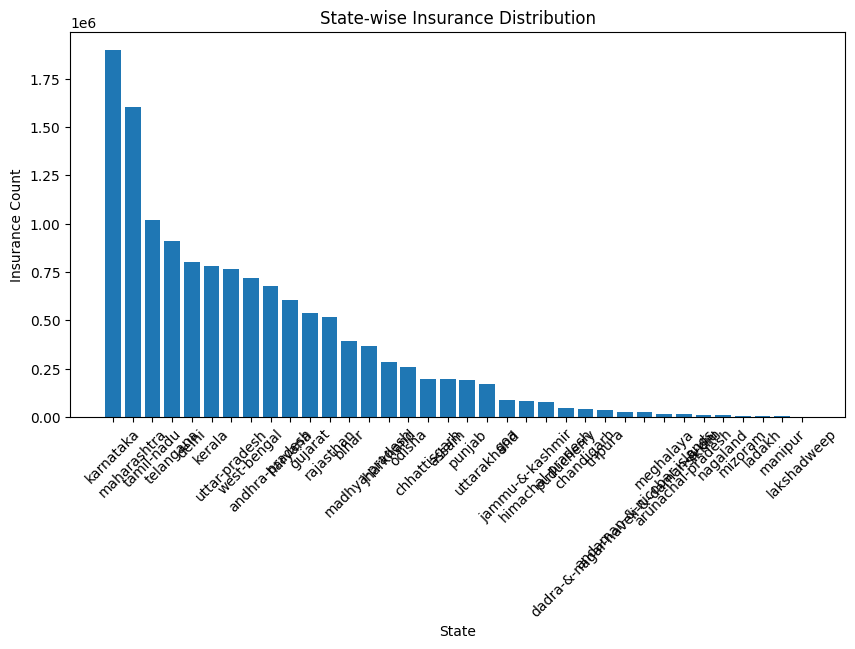

In [29]:
state_dist = df.groupby('state')['insurance_count'].sum().reset_index()

state_dist = state_dist.sort_values(by='insurance_count', ascending=False)

plt.figure(figsize=(10,5))
plt.bar(state_dist['state'], state_dist['insurance_count'])

plt.xticks(rotation=45)
plt.title("State-wise Insurance Distribution")
plt.xlabel("State")
plt.ylabel("Insurance Count")

plt.show()

Step:3 Contribution %

In [27]:
total = df_dist['insurance_count'].sum()
top_share = top10['insurance_count'].sum() / total * 100

print(f"Top 10 Contribution: {top_share:.2f}%")

Top 10 Contribution: 23.43%


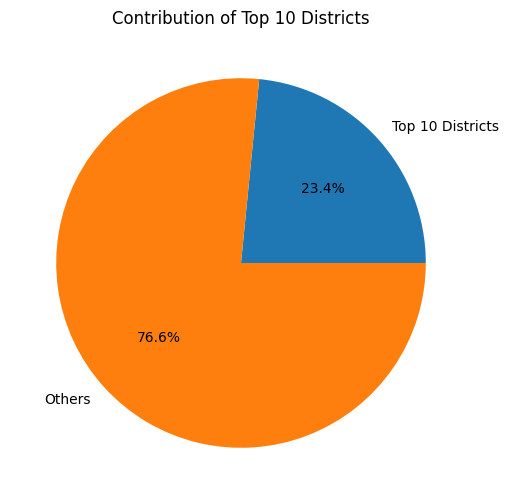

In [30]:
# Calculate values
top_value = top10['insurance_count'].sum()
others_value = total - top_value

# Plot
plt.figure(figsize=(6,6))
plt.pie([top_value, others_value],
        labels=['Top 10 Districts', 'Others'],
        autopct='%1.1f%%')

plt.title("Contribution of Top 10 Districts")
plt.show()

Insight 1: Districts from South indian states dominate the insurance market and the top 10 conributes to a total of 23.43%

Business Meaning: We can offer premium products and Add ons to these regions.

## Seasonal Trend Analysis


Step 1: Sun insurance Count

In [39]:
trend = df.groupby(['year', 'quarter'])['insurance_count'].sum().reset_index()

trend

,year,quarter,insurance_count
0,2020,2,197709
1,2020,3,326648
2,2020,4,219508
3,2021,1,281925
4,2021,2,323108
5,2021,3,342725
6,2021,4,489288
7,2022,1,577560
8,2022,2,593846
9,2022,3,753980


Step 2: Calculate Growth %

In [35]:
trend['growth_%'] = trend['insurance_count'].pct_change() * 100

print(trend)

    year  quarter  insurance_count  growth_%
0   2020        2           197709       NaN
1   2020        3           326648        65
2   2020        4           219508       -33
3   2021        1           281925        28
4   2021        2           323108        15
5   2021        3           342725         6
6   2021        4           489288        43
7   2022        1           577560        18
8   2022        2           593846         3
9   2022        3           753980        27
10  2022        4           966343        28
11  2023        1           879776        -9
12  2023        2           853872        -3
13  2023        3           963271        13
14  2023        4          1078955        12
15  2024        1          1139491         6
16  2024        2           995544       -13
17  2024        3          1097080        10
18  2024        4          1308681        19


Step 3: Identify Spikes & Drops

In [37]:
print(trend.sort_values(by='growth_%', ascending=False).head())

print(trend.sort_values(by='growth_%').head())

    year  quarter  insurance_count  growth_%
1   2020        3           326648        65
6   2021        4           489288        43
3   2021        1           281925        28
10  2022        4           966343        28
9   2022        3           753980        27
    year  quarter  insurance_count  growth_%
2   2020        4           219508       -33
16  2024        2           995544       -13
11  2023        1           879776        -9
12  2023        2           853872        -3
8   2022        2           593846         3


Step 4: Simple Seasonality Check (YoY Same Quarter)

In [38]:
pivot = trend.pivot(index='quarter', columns='year', values='insurance_count')

print(pivot)

year       2020    2021    2022      2023      2024
quarter                                            
1           NaN 281,925 577,560   879,776 1,139,491
2       197,709 323,108 593,846   853,872   995,544
3       326,648 342,725 753,980   963,271 1,097,080
4       219,508 489,288 966,343 1,078,955 1,308,681


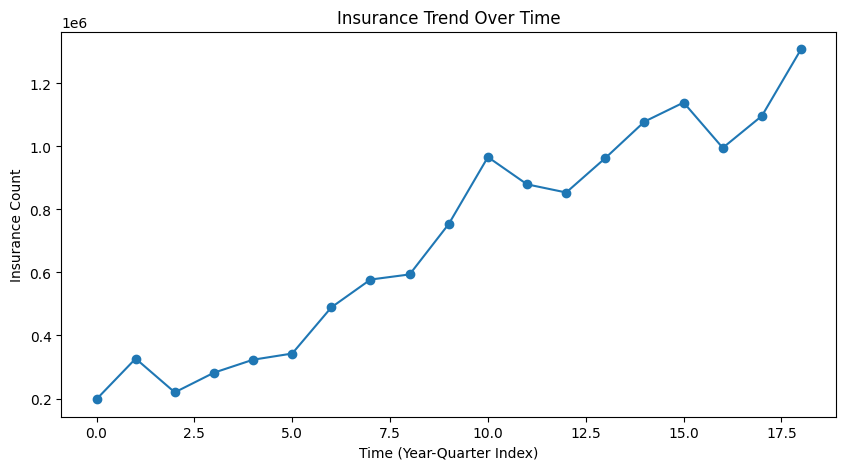

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(trend['insurance_count'], marker='o')

plt.title("Insurance Trend Over Time")
plt.xlabel("Time (Year-Quarter Index)")
plt.ylabel("Insurance Count")

plt.show()

Insight 1: Insurance demand shows sharp spikes in Q3 and Q4, indicating strong seasonal buying behavior.

Business meaning: Increased financial activity due to festivel seasons. so we can do is Push renewals + upsell campaigns .

## Ticket Size Analysis (User Spending Behavior)

Step 1: Calculate Avg Ticket

In [44]:
df['avg_ticket'] = df['insurance_amount'] / df['insurance_count']

df['avg_ticket']

0       1,518
1       1,327
2       1,225
3       1,492
4       1,241
         ... 
12271   1,147
12272   1,774
12273   1,288
12274   1,707
12275   1,592
Name: avg_ticket, Length: 12276, dtype: float64

Step 2: State-wise Avg Ticket

In [45]:
ticket_state = df.groupby('state')['avg_ticket'].mean().reset_index()

ticket_state

,state,avg_ticket
0,andaman-&-nicobar-islands,"1,451"
1,andhra-pradesh,"1,062"
2,arunachal-pradesh,"1,934"
3,assam,"1,271"
4,bihar,"1,042"
5,chandigarh,"1,250"
6,chhattisgarh,"1,211"
7,dadra-&-nagar-haveli-&-daman-&-diu,"1,681"
8,delhi,"1,065"
9,goa,"1,151"


Step 4: Sort

In [46]:
ticket_state = ticket_state.sort_values(by='avg_ticket', ascending=False)

print(ticket_state)

                                 state  avg_ticket
17                              ladakh       2,102
29                              sikkim       1,948
2                    arunachal-pradesh       1,934
21                             manipur       1,790
24                            nagaland       1,731
22                           meghalaya       1,694
7   dadra-&-nagar-haveli-&-daman-&-diu       1,681
13                     jammu-&-kashmir       1,555
23                             mizoram       1,544
12                    himachal-pradesh       1,513
0            andaman-&-nicobar-islands       1,451
18                         lakshadweep       1,416
34                         uttarakhand       1,401
27                              punjab       1,359
3                                assam       1,271
16                              kerala       1,269
5                           chandigarh       1,250
15                           karnataka       1,212
6                         chhat

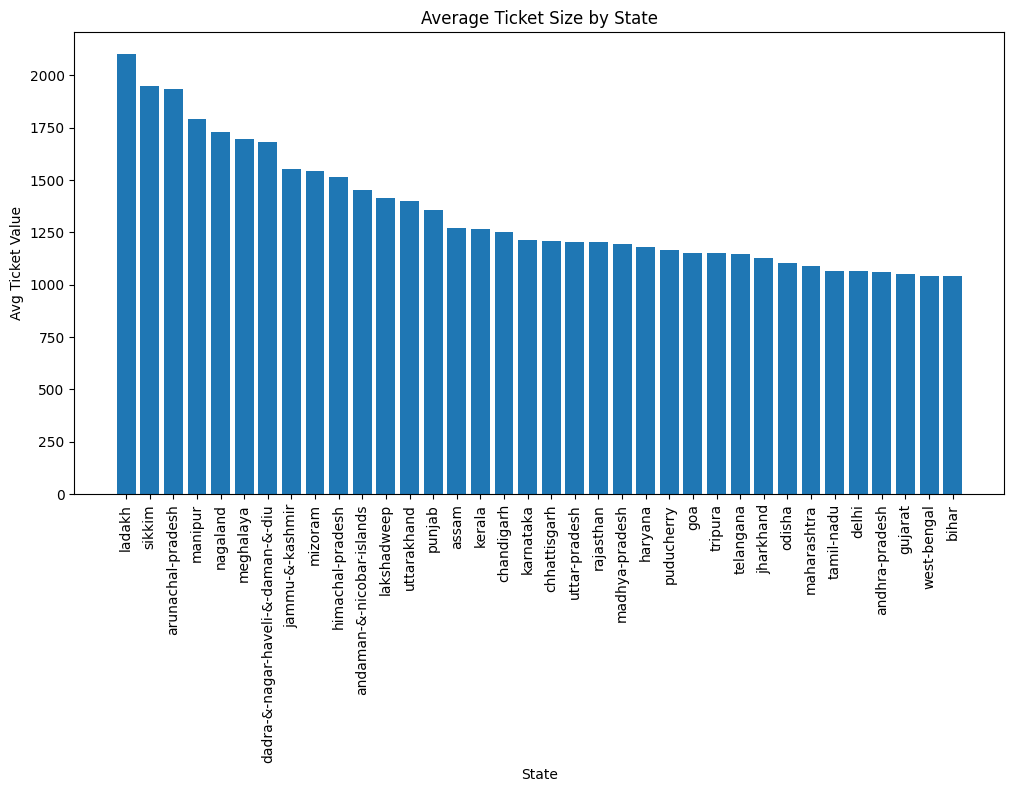

In [47]:
import matplotlib.pyplot as plt

# Sort data
ticket_state_sorted = ticket_state.sort_values(by='avg_ticket', ascending=False)

plt.figure(figsize=(12,6))

plt.bar(ticket_state_sorted['state'], ticket_state_sorted['avg_ticket'])

plt.xticks(rotation=90)
plt.title("Average Ticket Size by State")
plt.xlabel("State")
plt.ylabel("Avg Ticket Value")

plt.show()

Insight 1: Smaller and less populated states show higher average ticket size--Ladakh, Sikkim, Arunachal Pradesh, Manipur, Nagaland

Business Meaning: Fewer users, but higher spending per user-So Focus on quality over quantity and sell premium / high coverage plans.

Insight 2: Market Segmentation: 
        
        High Ticket → Premium markets

        Mid Ticket → Balanced markets

        Low Ticket → Price-sensitive markets

Business Meaning: One single pricing strategy will NOT work across India        
                  So either you can sell products based on market segmentation or else you can sell same product with different pricing strategy.

## Growth vs Penetration Matrix

Step 1: State-wise Total Transactions

In [58]:
state_total = df.groupby('state')['insurance_count'].sum().reset_index()
state_total.rename(columns={'insurance_count': 'total_txn'}, inplace=True)
state_total

,state,total_txn
0,andaman-&-nicobar-islands,24588
1,andhra-pradesh,679302
2,arunachal-pradesh,15091
3,assam,196945
4,bihar,392051
5,chandigarh,39175
6,chhattisgarh,197993
7,dadra-&-nagar-haveli-&-daman-&-diu,27584
8,delhi,803519
9,goa,86497


Step 2: Calculate Growth per State

In [59]:
#year wise data
state_year = df.groupby(['state', 'year'])['insurance_count'].sum().reset_index()
state_year

,state,year,insurance_count
0,andaman-&-nicobar-islands,2020,330
1,andaman-&-nicobar-islands,2021,2569
2,andaman-&-nicobar-islands,2022,5316
3,andaman-&-nicobar-islands,2023,7034
4,andaman-&-nicobar-islands,2024,9339
...,...,...,...
175,west-bengal,2020,26829
176,west-bengal,2021,76146
177,west-bengal,2022,149178
178,west-bengal,2023,206095


In [60]:
# Then growth:
state_year['growth_%'] = state_year.groupby('state')['insurance_count'].pct_change() * 100
state_year['growth_%']

0     NaN
1     678
2     107
3      32
4      33
       ..
175   NaN
176   184
177    96
178    38
179    27
Name: growth_%, Length: 180, dtype: float64

In [61]:
# Get latest growth
latest_growth = state_year.sort_values(['state', 'year']).groupby('state').tail(1)
latest_growth = latest_growth[['state', 'growth_%']]
latest_growth

,state,growth_%
4,andaman-&-nicobar-islands,33
9,andhra-pradesh,9
14,arunachal-pradesh,37
19,assam,5
24,bihar,39
29,chandigarh,9
34,chhattisgarh,43
39,dadra-&-nagar-haveli-&-daman-&-diu,32
44,delhi,14
49,goa,28


Step 3: Calculate Penetration (Share)

In [66]:
# convert to float
state_total['total_txn'] = state_total['total_txn'].astype(float)

total_all = float(state_total['total_txn'].sum())

state_total['penetration'] = state_total['total_txn'] / total_all

In [68]:
total_all = state_total['total_txn'].sum()

state_total['penetration'] = (state_total['total_txn'] / total_all) * 100

state_total['penetration']


0     0
1     5
2     0
3     1
4     3
5     0
6     1
7     0
8     6
9     1
10    4
11    5
12    1
13    1
14    2
15   14
16    6
17    0
18    0
19    3
20   12
21    0
22    0
23    0
24    0
25    2
26    0
27    1
28    4
29    0
30    8
31    7
32    0
33    6
34    1
35    5
Name: penetration, dtype: float64

Step 4: Merge Growth + Penetration

In [71]:
matrix = pd.merge(state_total, latest_growth, on='state')
matrix

,state,total_txn,penetration,growth_%
0,andaman-&-nicobar-islands,"24,588",0,33
1,andhra-pradesh,"679,302",5,9
2,arunachal-pradesh,"15,091",0,37
3,assam,"196,945",1,5
4,bihar,"392,051",3,39
5,chandigarh,"39,175",0,9
6,chhattisgarh,"197,993",1,43
7,dadra-&-nagar-haveli-&-daman-&-diu,"27,584",0,32
8,delhi,"803,519",6,14
9,goa,"86,497",1,28


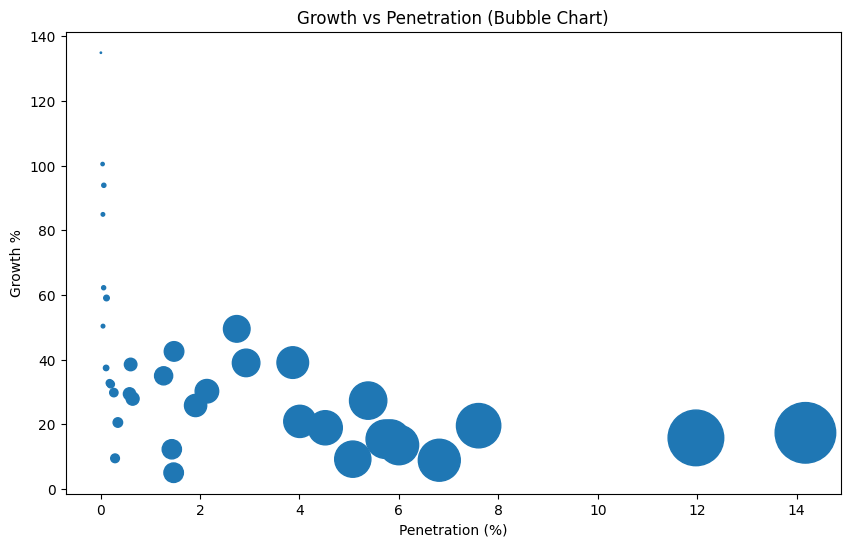

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    matrix['penetration'],
    matrix['growth_%'],
    s=matrix['total_txn'] / 1000  # adjust size
)

plt.xlabel("Penetration (%)")
plt.ylabel("Growth %")
plt.title("Growth vs Penetration (Bubble Chart)")

plt.show()

Insight 1: Expansion Markets---High Growth + Low Penetration---These states are growing fast but still have low market share
           Eg: Bihar (39%, 3%)

               Chhattisgarh (43%, 1%)

               Madhya Pradesh (50%, 3%)

               Rajasthan (39%, 4%)

               Jharkhand (30%, 2%)

Business Meaning: 1. Huge untapped opportunity
                  2. Users are starting to adopt insurance

Business Strategy: 1. Increase marketing & awareness 
                   2. Offer affordable entry-level plans
                   3. Focus on user acquisition                 

# 5. User Registration Analysis - Aggregated User

In [74]:
from dotenv import load_dotenv
import os
import mysql.connector
import pandas as pd

# Load environment variables
load_dotenv()

conn = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

query = "SELECT * FROM aggregated_user;"
df = pd.read_sql(query, conn)

df.head()

C:\Users\Vigne\AppData\Local\Temp\ipykernel_6728\2454658559.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,state,year,quarter,device_brand,registered_users,app_opens,device_count,device_percentage
0,1,maharashtra,2021,2,Xiaomi,39664697,1208083592,9764252,0
1,2,maharashtra,2021,2,Samsung,39664697,1208083592,8511194,0
2,3,maharashtra,2021,2,Vivo,39664697,1208083592,7509629,0
3,4,maharashtra,2021,2,Oppo,39664697,1208083592,5487836,0
4,5,maharashtra,2021,2,Realme,39664697,1208083592,2003392,0


In [75]:
agg_user = pd.read_sql("SELECT * FROM aggregated_user", conn)

print("Data loaded ✅")
print(top_ins.shape)

Data loaded ✅
(12276, 8)


C:\Users\Vigne\AppData\Local\Temp\ipykernel_6728\2227044912.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  agg_user = pd.read_sql("SELECT * FROM aggregated_user", conn)


In [76]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [77]:
agg_user.head()

,id,state,year,quarter,device_brand,registered_users,app_opens,device_count,device_percentage
0,1,maharashtra,2021,2,Xiaomi,39664697,1208083592,9764252,0
1,2,maharashtra,2021,2,Samsung,39664697,1208083592,8511194,0
2,3,maharashtra,2021,2,Vivo,39664697,1208083592,7509629,0
3,4,maharashtra,2021,2,Oppo,39664697,1208083592,5487836,0
4,5,maharashtra,2021,2,Realme,39664697,1208083592,2003392,0


In [78]:
agg_user.columns

Index(['id', 'state', 'year', 'quarter', 'device_brand', 'registered_users',
       'app_opens', 'device_count', 'device_percentage'],
      dtype='str')

In [79]:
agg_user.shape

(6732, 9)

In [80]:
agg_user.info()

<class 'pandas.DataFrame'>
RangeIndex: 6732 entries, 0 to 6731
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 6732 non-null   int64  
 1   state              6732 non-null   str    
 2   year               6732 non-null   int64  
 3   quarter            6732 non-null   int64  
 4   device_brand       6732 non-null   str    
 5   registered_users   6732 non-null   int64  
 6   app_opens          6732 non-null   int64  
 7   device_count       6732 non-null   int64  
 8   device_percentage  6732 non-null   float64
dtypes: float64(1), int64(6), str(2)
memory usage: 473.5 KB


In [81]:
agg_user.describe()

,id,year,quarter,registered_users,app_opens,device_count,device_percentage
count,"6,732","6,732","6,732","6,732","6,732","6,732","6,732"
mean,"3,366","2,020",2,"5,654,126","151,006,870","514,011",0
std,"1,944",1,1,"7,955,764","323,669,912","1,081,772",0
min,1,"2,018",1,501,0,10,0
25%,"1,684","2,019",1,"191,858",0,"9,354",0
50%,"3,366","2,020",2,"1,978,676","5,893,784","84,722",0
75%,"5,049","2,021",3,"8,393,058","149,651,011","455,581",0
max,"6,732","2,022",4,"48,227,630","2,570,606,469","11,340,940",0


##  User Growth Analysis

Step 1: Group by Year & Quarter

In [82]:
growth = df.groupby(['year', 'quarter'])['registered_users'].sum().reset_index()

growth

,year,quarter,registered_users
0,2018,1,515654183
1,2018,2,700128099
2,2018,3,880116479
3,2018,4,1124877831
4,2019,1,1357754068
5,2019,2,1559884194
6,2019,3,1752226509
7,2019,4,1961062587
8,2020,1,2173319049
9,2020,2,2408951556


Step 2: Sort

In [83]:
growth = growth.sort_values(by=['year', 'quarter'])

growth

,year,quarter,registered_users
0,2018,1,515654183
1,2018,2,700128099
2,2018,3,880116479
3,2018,4,1124877831
4,2019,1,1357754068
5,2019,2,1559884194
6,2019,3,1752226509
7,2019,4,1961062587
8,2020,1,2173319049
9,2020,2,2408951556


Step 3: Calculate Growth %

In [84]:
growth['growth_%'] = growth['registered_users'].pct_change() * 100

print(growth)

    year  quarter  registered_users  growth_%
0   2018        1         515654183       NaN
1   2018        2         700128099        36
2   2018        3         880116479        26
3   2018        4        1124877831        28
4   2019        1        1357754068        21
5   2019        2        1559884194        15
6   2019        3        1752226509        12
7   2019        4        1961062587        12
8   2020        1        2173319049        11
9   2020        2        2408951556        11
10  2020        3        2652857856        10
11  2020        4        2906974774        10
12  2021        1        3134829621         8
13  2021        2        3357828111         7
14  2021        3        3611892416         8
15  2021        4        3862762882         7
16  2022        1        4102456897         6


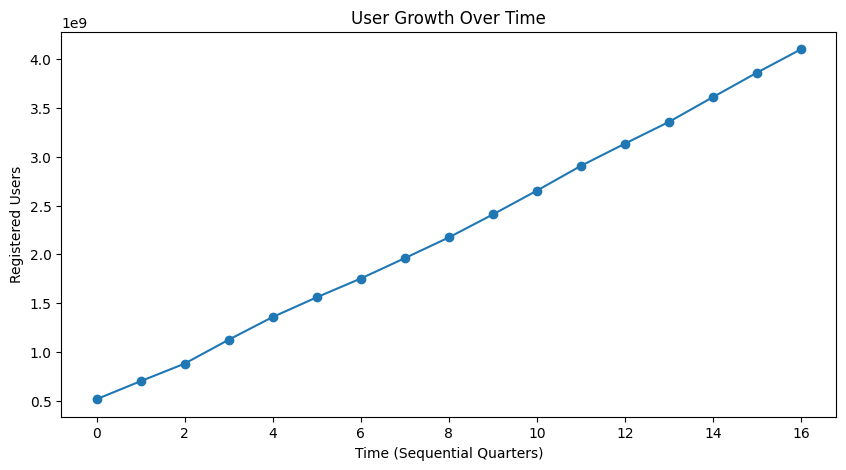

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(growth['registered_users'], marker='o')

plt.title("User Growth Over Time")
plt.xlabel("Time (Sequential Quarters)")
plt.ylabel("Registered Users")

plt.show()

Insight 1: 4.1 Billion users (cumulative count metric)

Business Meaning: Huge user base = massive cross-sell opportunity

Insight 2: Early growth was very high, but it’s now stabilizing.

Business Meaning: So instead of focusing only on acquiring users, the business should now focus on monetizing the existing user base through products like insurance.

## State-wise User Distribution-Geographic Analysis

Step 1: Group by State

In [89]:
state_users = df.groupby('state')['registered_users'].sum().reset_index()

state_users

,state,registered_users
0,andaman-&-nicobar-islands,6857906
1,andhra-pradesh,2479563185
2,arunachal-pradesh,30861270
3,assam,434295521
4,bihar,1839927870
5,chandigarh,58691270
6,chhattisgarh,595506054
7,dadra-&-nagar-haveli-&-daman-&-diu,42861709
8,delhi,1470469429
9,goa,75290424


Step 2: Sort

In [90]:
state_users = state_users.sort_values(by='registered_users', ascending=False)

print(state_users)

                                 state  registered_users
20                         maharashtra        4972825121
33                       uttar-pradesh        3915665963
15                           karnataka        3205100580
1                       andhra-pradesh        2479563185
28                           rajasthan        2372101468
31                           telangana        2330985283
35                         west-bengal        2267427525
30                          tamil-nadu        2130315308
10                             gujarat        1988044388
19                      madhya-pradesh        1987286906
4                                bihar        1839927870
8                                delhi        1470469429
11                             haryana        1340601702
25                              odisha        1260386677
16                              kerala         843288336
27                              punjab         730723972
14                           jh

Step 3: Get Top 10 States

In [91]:
top10_states = state_users.head(10)

print(top10_states)

             state  registered_users
20     maharashtra        4972825121
33   uttar-pradesh        3915665963
15       karnataka        3205100580
1   andhra-pradesh        2479563185
28       rajasthan        2372101468
31       telangana        2330985283
35     west-bengal        2267427525
30      tamil-nadu        2130315308
10         gujarat        1988044388
19  madhya-pradesh        1987286906


<BarContainer object of 10 artists>

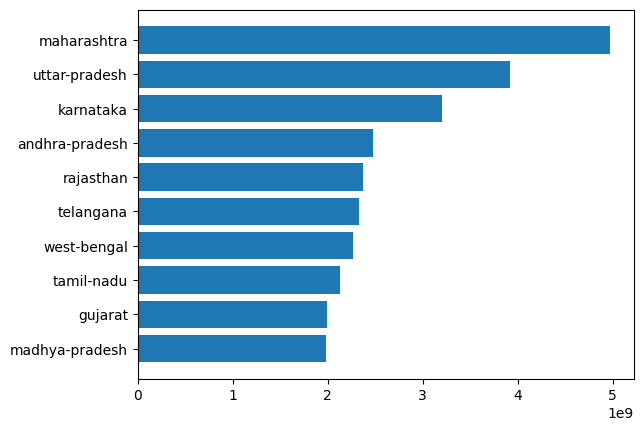

In [97]:
import matplotlib.pyplot as plt

top10_states = top10_states.sort_values(by='registered_users', ascending=True)

plt.barh(top10_states['state'], top10_states['registered_users'])

Insight 1: Tier-1 & Digitally Advanced States Lead
          Eg: Karnataka, Telangana, Tamil Nadu, Delhi

Business Meaning: Users are more comfortable with digital finance          

Strategy:  Launch Advanced financial products also sell digital insurance plans.

Insight 2: Large Population States = Huge Opportunity
          Eg: Bihar, Uttar Pradesh, Madhya Pradesh

Business Meaning: High user numbers due to population, but not fully monetized yet          

Strategy:  Mass-market campaigns and initially launch Affordable insurance.

## User Engagement Analysis

Step 1: Create Engagement Metric

In [ ]:
# How many times a user opens the app (on average)
df['engagement'] = df['app_opens'] / df['registered_users']

df['engagement']

0      30
1      30
2      30
3      30
4      30
       ..
6727   33
6728   33
6729   33
6730   33
6731   33
Name: engagement, Length: 6732, dtype: float64

Step 2: State-wise Engagement

In [101]:
engagement_state = df.groupby('state')['engagement'].mean().reset_index()

engagement_state

,state,engagement
0,andaman-&-nicobar-islands,14
1,andhra-pradesh,31
2,arunachal-pradesh,23
3,assam,16
4,bihar,15
5,chandigarh,10
6,chhattisgarh,22
7,dadra-&-nagar-haveli-&-daman-&-diu,13
8,delhi,14
9,goa,14


Step 3: Rank States

In [102]:
engagement_state = engagement_state.sort_values(by='engagement', ascending=False)

print(engagement_state)

                                 state  engagement
1                       andhra-pradesh          31
31                           telangana          30
28                           rajasthan          29
15                           karnataka          28
19                      madhya-pradesh          25
2                    arunachal-pradesh          23
25                              odisha          23
6                         chhattisgarh          22
17                              ladakh          22
23                             mizoram          20
20                         maharashtra          19
14                           jharkhand          19
22                           meghalaya          18
24                            nagaland          17
3                                assam          16
11                             haryana          16
29                              sikkim          16
4                                bihar          15
34                         utta

Step 4: Top & Bottom States

In [103]:
# Top engaged states
top_engagement = engagement_state.head(10)

# Low engaged states
low_engagement = engagement_state.tail(10)

print(top_engagement)
print(low_engagement)

                state  engagement
1      andhra-pradesh          31
31          telangana          30
28          rajasthan          29
15          karnataka          28
19     madhya-pradesh          25
2   arunachal-pradesh          23
25             odisha          23
6        chhattisgarh          22
17             ladakh          22
23            mizoram          20
               state  engagement
12  himachal-pradesh          12
10           gujarat          12
35       west-bengal          12
32           tripura          12
13   jammu-&-kashmir          12
26        puducherry          11
27            punjab          10
5         chandigarh          10
16            kerala           9
18       lakshadweep           6


In [112]:
import plotly.express as px

fig = px.scatter(
    engagement_state,
    x='registered_users',
    y='engagement',
    hover_name='state',   # shows state on hover instead of text
    size='registered_users',
    title='User Engagement vs User Base'
)

fig.update_layout(
    xaxis_title='Registered Users',
    yaxis_title='Engagement'
)

fig.show()

In [ ]:
# Highlight only top states.

top_states = engagement_state.sort_values(by='registered_users', ascending=False).head(10)

fig = px.scatter(
    top_states,
    x='registered_users',
    y='engagement',
    hover_name='state',
    size='registered_users',
    title='Top States: Engagement vs Users'
)

fig.show()

Insight 1: High Engagement States = Strong User Behavior----Users in these states open the app very frequently   
          Eg: Andhra Pradesh, Telangana, Rajasthan, Karnataka

Business Meaning: High trust and Users are actively using the platform.-- These are your BEST monetization markets.

Strategy:  Insurance offers

           Loans & credit

           Investment products

Insight 2: Kerala---> good digital state but low engagement

Business Meaning: High literacy/digital access ≠ high engagement-----Competition may be higher or Users may prefer other apps.

Strategy:  Analyze the market through surveys and implement targeted re-engagement strategies based on the insights obtained.

## Device Brand Market Share Analysis

Step 1: Group by Device Brand

In [116]:
brand_share = df.groupby('device_brand')['device_count'].sum().reset_index()

brand_share

,device_brand,device_count
0,Apple,95947314
1,Asus,4295498
2,COOLPAD,10
3,Gionee,3082772
4,HMD Global,336632
5,Huawei,57129693
6,Infinix,5142870
7,Lava,1530109
8,Lenovo,42564548
9,Lyf,1271


Step 2: Sort

In [117]:
brand_share = brand_share.sort_values(by='device_count', ascending=False)

print(brand_share)

   device_brand  device_count
19       Xiaomi     869562617
16      Samsung     671603711
18         Vivo     625415019
13         Oppo     420250245
14       Others     282950234
15       Realme     219973222
0         Apple      95947314
11     Motorola      73340734
12      OnePlus      63677211
5        Huawei      57129693
8        Lenovo      42564548
17        Tecno      12388623
10     Micromax      11132859
6       Infinix       5142870
1          Asus       4295498
3        Gionee       3082772
7          Lava       1530109
4    HMD Global        336632
9           Lyf          1271
2       COOLPAD            10


Step 3: Calculate Market Share %

In [118]:
brand_share['share_%'] = (
    brand_share['device_count'] / brand_share['device_count'].sum()
) * 100

brand_share['share_%']

19   25
16   19
18   18
13   12
14    8
15    6
0     3
11    2
12    2
5     2
8     1
17    0
10    0
6     0
1     0
3     0
7     0
4     0
9     0
2     0
Name: share_%, dtype: float64

Step 4: Top 10 Brands

In [119]:
top_brands = brand_share.head(10)

print(top_brands)

   device_brand  device_count  share_%
19       Xiaomi     869562617       25
16      Samsung     671603711       19
18         Vivo     625415019       18
13         Oppo     420250245       12
14       Others     282950234        8
15       Realme     219973222        6
0         Apple      95947314        3
11     Motorola      73340734        2
12      OnePlus      63677211        2
5        Huawei      57129693        2


In [121]:
import plotly.express as px

fig = px.pie(
    brand_share.head(10),
    names='device_brand',
    values='share_%',
    hole=0.5,   # makes it donut
    title='Top Device Brands Market Share'
)

fig.show()

Insight 1: Market Dominated by Few Brands
          Eg: Xiaomi (25%)
              Samsung (19%)
              Vivo (18%)

              Together ≈ 62% of total market

Business Meaning: A few brands dominate the majority of users and all are Android Ecosystem devices and define the core user experience.

Strategy:  Android app stability

           Device compatibility

           Lightweight app versions

Insight 2: Low Share of Apple Users (3%)

Business Meaning: There is only a small segment of apple device users but high-value segment.

Strategy: Push Premium insurance

          High-value financial products

## Device vs Engagement Analysis

Step 1: Group by Device Brand

In [123]:
device_engagement = df.groupby('device_brand').agg({
    'registered_users': 'sum',
    'app_opens': 'sum'
}).reset_index()

device_engagement

,device_brand,registered_users,app_opens
0,Apple,3091083052,84675446358
1,Asus,252218289,3965320634
2,COOLPAD,501,0
3,Gionee,217450708,4182563578
4,HMD Global,39932553,906168456
5,Huawei,3235551317,88424845540
6,Infinix,355287519,9494116101
7,Lava,120949478,2306042775
8,Lenovo,2547296210,60117510485
9,Lyf,75980,0


Step 2: Calculate Engagement

In [124]:
device_engagement['engagement'] = (
    device_engagement['app_opens'] / device_engagement['registered_users']
)

device_engagement['engagement']

0    27
1    16
2     0
3    19
4    23
5    27
6    27
7    19
8    24
9     0
10   18
11   27
12   29
13   27
14   27
15   27
16   27
17   37
18   27
19   27
Name: engagement, dtype: float64

Step 3: Sort

In [125]:
device_engagement = device_engagement.sort_values(by='engagement', ascending=False)

print(device_engagement)

   device_brand  registered_users    app_opens  engagement
17        Tecno         871353985  31818603398          37
12      OnePlus        2693291065  77925898204          29
0         Apple        3091083052  84675446358          27
5        Huawei        3235551317  88424845540          27
6       Infinix         355287519   9494116101          27
18         Vivo        3460325192  92416204449          27
16      Samsung        3460325192  92416204449          27
19       Xiaomi        3460325192  92416204449          27
13         Oppo        3460325192  92416204449          27
14       Others        3460325192  92416204449          27
15       Realme        3460325192  92416204449          27
11     Motorola        3339301076  88529569238          27
8        Lenovo        2547296210  60117510485          24
4    HMD Global          39932553    906168456          23
3        Gionee         217450708   4182563578          19
7          Lava         120949478   2306042775          

Step 4: Top & Bottom Devices

In [126]:
top_devices = device_engagement.head(10)
low_devices = device_engagement.tail(10)

print(top_devices)
print(low_devices)

   device_brand  registered_users    app_opens  engagement
17        Tecno         871353985  31818603398          37
12      OnePlus        2693291065  77925898204          29
0         Apple        3091083052  84675446358          27
5        Huawei        3235551317  88424845540          27
6       Infinix         355287519   9494116101          27
18         Vivo        3460325192  92416204449          27
16      Samsung        3460325192  92416204449          27
19       Xiaomi        3460325192  92416204449          27
13         Oppo        3460325192  92416204449          27
14       Others        3460325192  92416204449          27
   device_brand  registered_users    app_opens  engagement
15       Realme        3460325192  92416204449          27
11     Motorola        3339301076  88529569238          27
8        Lenovo        2547296210  60117510485          24
4    HMD Global          39932553    906168456          23
3        Gionee         217450708   4182563578          

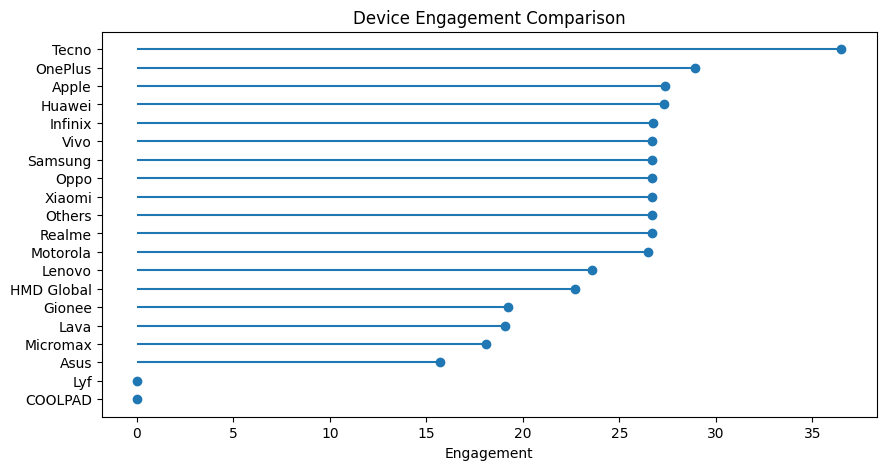

In [129]:
import matplotlib.pyplot as plt

device_engagement = device_engagement.sort_values(by='engagement')

plt.figure(figsize=(10,5))

plt.hlines(y=device_engagement['device_brand'],
           xmin=0,
           xmax=device_engagement['engagement'])

plt.plot(device_engagement['engagement'],
         device_engagement['device_brand'],
         "o")

plt.xlabel("Engagement")
plt.title("Device Engagement Comparison")

plt.show()

Insight 1: Premium Devices Show Strong Engagement
          Eg: OnePlus --> 29
              Apple --> 27

Business Meaning: High purchasing power + active usage

Strategy: Premium insurance

          Investment products

          High-value services

Insight 2: Tecno Users = Most Engaged
          Eg: Tecno --> Engagement = 37

          Tecno users are extremely active compared to others
              

Business Meaning: Outliers- Tecno users are extremely active compared to others.
                  
                  Budget users

                  Heavy app usage behavior

Strategy: Frequent offers

          Cashback

          Low-cost insurance